# Customer segmentation
_F. Daniel (September 2017)_
____

This notebook aims at analyzing the content of an E-commerce database that lists purchases made by $\sim$4000 customers over a period of one year (from 2010/12/01 to 2011/12/09). Based on this analysis, I develop a model that allows to anticipate the purchases that will be made by a new customer, during the following year and this, from its first purchase. <br>

___
**Acknowledgement**: many thanks to [J. Abécassis](https://www.kaggle.com/judithabk6) for the advices and help provided during the writing of this notebook 
___
**1. Data Preparation**

**2. Exploring the content of variables**

   - 2.1 Countries
   - 2.2 Customers and products
       * 2.2.1 Cancelling orders
       * 2.2.2 StockCode
       * 2.2.3 Basket price

**3. Insight on product categories**

   - 3.1 Product description 
   - 3.2 Defining product categories 
       * 3.2.1 Data encoding
       * 3.2.2 Clusters of products
       * 3.2.3 Characterizing the content of clusters
   
**4. Customer categories**

   - 4.1 Formating data
       * 4.1.1 Grouping products 
       * 4.1.2 Time spliting of the dataset
       * 4.1.3 Grouping orders 
   - 4.2 Creating customer categories
       * 4.2.1 Data enconding
       * 4.2.2 Creating categories

**5. Classifying customers**

   - 5.1 Support Vector Machine Classifier (SVC)
       * 5.1.1 Confusion matrix
       * 5.1.2 Leraning curves 
   - 5.2 Logistic regression 
   - 5.3 k-Nearest Neighbors
   - 5.4 Decision Tree
   - 5.5 Random Forest
   - 5.6 AdaBoost
   - 5.7 Gradient Boosting Classifier
   - 5.8 Let's vote !
   
**6. Testing the predictions**

**7. Conclusion**

## 1. Data preparation

As a first step, I load all the modules that will be used in this notebook:

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import datetime, nltk, warnings
import matplotlib.cm as cm
import itertools
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn import preprocessing, model_selection, metrics, feature_selection
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn import neighbors, linear_model, svm, tree, ensemble
from wordcloud import WordCloud, STOPWORDS
from sklearn.ensemble import AdaBoostClassifier
from sklearn.decomposition import PCA
from IPython.display import display, HTML
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)
%matplotlib inline

Then, I load the data. Once done, I also give some basic informations on the content of the dataframe: the type of the various variables, the number of null values and their percentage with respect to the total number of entries:

In [9]:
import pandas as pd

# 1. Load your dataset (adjust path if needed)
df_initial = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# 2. Check actual column names
print(df_initial.columns)

# 3. Convert the correct date column to datetime
df_initial['Order Date'] = pd.to_datetime(df_initial['Order Date'])

# 4. Build summary table
tab_info = pd.DataFrame(df_initial.dtypes).T.rename(index={0: 'column type'})

tab_info = pd.concat([
    tab_info,
    pd.DataFrame(df_initial.isnull().sum()).T.rename(index={0: 'null values (nb)'})
])

tab_info = pd.concat([
    tab_info,
    pd.DataFrame(df_initial.isnull().sum() / df_initial.shape[0] * 100).T.rename(index={0: 'null values (%)'})
])

# 5. Display summary
display(tab_info)


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
column type,int64,str,datetime64[us],str,str,str,str,str,str,str,...,int64,str,str,str,str,str,float64,int64,float64,float64
null values (nb),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
null values (%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


While looking at the number of null values in the dataframe, it is interesting to note that $\sim$25% of the entries are not assigned to a particular customer. With the data available, it is impossible to impute values for the user and these entries are thus useless for the current exercise. So I delete them from the dataframe:

In [10]:
tab_info = pd.DataFrame(df_initial.dtypes).T.rename(index={0:'column type'})

tab_info = pd.concat([
    tab_info,
    pd.DataFrame(df_initial.isnull().sum()).T.rename(index={0:'null values (nb)'})
])

tab_info = pd.concat([
    tab_info,
    pd.DataFrame(df_initial.isnull().sum()/df_initial.shape[0]*100).T.rename(index={0:'null values (%)'})
])

display(tab_info)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
column type,int64,str,datetime64[us],str,str,str,str,str,str,str,...,int64,str,str,str,str,str,float64,int64,float64,float64
null values (nb),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
null values (%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


OK, therefore, by removing these entries we end up with a dataframe filled at 100% for all variables! Finally, I check for duplicate entries and delete them:

In [11]:
print('Entrées dupliquées: {}'.format(df_initial.duplicated().sum()))
df_initial.drop_duplicates(inplace = True)

Entrées dupliquées: 0


___
## 2. Exploring the content of variables

This dataframe contains 8 variables that correspond to: 

**InvoiceNo**: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.  <br>
**StockCode**: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product. <br>
**Description**: Product (item) name. Nominal. <br>
**Quantity**: The quantities of each product (item) per transaction. Numeric.	<br>
**InvoiceDate**: Invice Date and time. Numeric, the day and time when each transaction was generated. <br>
**UnitPrice**: Unit price. Numeric, Product price per unit in sterling. <br>
**CustomerID**: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer. <br>
**Country**: Country name. Nominal, the name of the country where each customer resides.<br>

___
### 2.1 Countries

Here, I quickly look at the countries from which orders were made:

In [13]:
# Corrected version for Superstore dataset
temp = df_initial[['Customer ID', 'Order ID', 'Country']] \
    .groupby(['Customer ID', 'Order ID', 'Country']).count()

temp = temp.reset_index(drop=False)

countries = temp['Country'].value_counts()
print('Nb. de pays dans le dataframe: {}'.format(len(countries)))


Nb. de pays dans le dataframe: 1


and show the result on a chloropleth map:

We see that the dataset is largely dominated by orders made from the UK.

___
### 2.2 Customers and products

The dataframe contains $\sim$400,000 entries. What are the number of users and products in these entries ?

In [15]:
import pandas as pd

# Count products, transactions, customers
summary = pd.DataFrame([{
    'products': df_initial['Product Name'].nunique(),      # unique products
    'transactions': df_initial['Order ID'].nunique(),      # unique orders
    'customers': df_initial['Customer ID'].nunique()       # unique customers
}], columns=['products', 'transactions', 'customers'], index=['quantity'])

print(summary)


          products  transactions  customers
quantity      1850          5009        793


It can be seen that the data concern 4372 users and that they bought 3684 different products. The total number of transactions carried out is of the order of $\sim$22'000.

Now I will determine the number of products purchased in every transaction:

In [17]:
import pandas as pd

# Group by Customer ID and Order ID
temp = df_initial.groupby(by=['Customer ID', 'Order ID'], as_index=False)['Order Date'].count()

# Rename column to show number of products per basket
nb_products_per_basket = temp.rename(columns={'Order Date': 'Number of products'})

# Show first 10 rows sorted by Customer ID
print(nb_products_per_basket.sort_values('Customer ID').head(10))


   Customer ID        Order ID  Number of products
0     AA-10315  CA-2014-128055                   2
1     AA-10315  CA-2014-138100                   2
2     AA-10315  CA-2015-121391                   1
3     AA-10315  CA-2016-103982                   4
4     AA-10315  CA-2017-147039                   2
13    AA-10375  US-2017-169488                   2
12    AA-10375  CA-2017-100230                   3
11    AA-10375  CA-2016-131065                   3
9     AA-10375  CA-2015-140921                   2
10    AA-10375  CA-2016-126613                   1


The first lines of this list shows several things worthy of interest:
- the existence of entries with the prefix C for the **InvoiceNo** variable: this indicates transactions that have been canceled
- the existence of users who only came once and only purchased one product (e.g. nº12346)
- the existence of frequent users that buy a large number of items at each order

___
#### 2.2.1 Cancelling orders

First of all, I count the number of transactions corresponding to canceled orders:

In [19]:
# Count products per basket (order)
temp = df_initial.groupby(by=['Customer ID', 'Order ID'], as_index=False)['Product Name'].count()

# Rename column to show number of products per basket
nb_products_per_basket = temp.rename(columns={'Product Name': 'Number of products'})

# Flag canceled orders: in Superstore, canceled orders are usually marked differently.
# If your dataset uses 'Order ID' with a "C" prefix for canceled orders, you can check like this:
nb_products_per_basket['order_canceled'] = nb_products_per_basket['Order ID'].apply(lambda x: int('C' in str(x)))

# Display first 5 rows
display(nb_products_per_basket.head())

# Calculate cancellation stats
n1 = nb_products_per_basket['order_canceled'].sum()
n2 = nb_products_per_basket.shape[0]
print('Number of orders canceled: {}/{} ({:.2f}%)'.format(n1, n2, n1/n2*100))


,Customer ID,Order ID,Number of products,order_canceled
0,AA-10315,CA-2014-128055,2,1
1,AA-10315,CA-2014-138100,2,1
2,AA-10315,CA-2015-121391,1,1
3,AA-10315,CA-2016-103982,4,1
4,AA-10315,CA-2017-147039,2,1


Number of orders canceled: 4195/5009 (83.75%)


We note that the number of cancellations is quite large ($\sim$16% of the total number of transactions).
Now, let's look at the first lines of the dataframe:

In [22]:
# Sort by Customer ID and show first 5 rows
display(df_initial.sort_values('Customer ID').head(5))


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2229,2230,CA-2014-128055,2014-03-31,4/5/2014,Standard Class,AA-10315,Alex Avila,Consumer,United States,San Francisco,...,94122,West,OFF-BI-10004390,Office Supplies,Binders,GBC DocuBind 200 Manual Binding Machine,673.568,2,0.2,252.5880
1160,1161,CA-2017-147039,2017-06-29,7/4/2017,Standard Class,AA-10315,Alex Avila,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10004654,Office Supplies,Binders,Avery Binding System Hidden Tab Executive Styl...,11.540,2,0.0,5.7700
2230,2231,CA-2014-128055,2014-03-31,4/5/2014,Standard Class,AA-10315,Alex Avila,Consumer,United States,San Francisco,...,94122,West,OFF-AP-10002765,Office Supplies,Appliances,Fellowes Advanced Computer Series Surge Protec...,52.980,2,0.0,14.8344
1159,1160,CA-2017-147039,2017-06-29,7/4/2017,Standard Class,AA-10315,Alex Avila,Consumer,United States,Minneapolis,...,55407,Central,OFF-AP-10000576,Office Supplies,Appliances,"Belkin 325VA UPS Surge Protector, 6'",362.940,3,0.0,90.7350
7469,7470,CA-2014-138100,2014-09-15,9/20/2014,Standard Class,AA-10315,Alex Avila,Consumer,United States,New York City,...,10011,East,FUR-FU-10002456,Furniture,Furnishings,"Master Caster Door Stop, Large Neon Orange",14.560,2,0.0,6.2608


On these few lines, we see that when an order is canceled, we have another transactions in the dataframe, mostly identical except for the **Quantity** and **InvoiceDate** variables. I decide to check if this is true for all the entries.
To do this, I decide to locate the entries that indicate a negative quantity and check if there is *systematically* an order indicating the same quantity (but positive), with the same description (**CustomerID**, **Description** and **UnitPrice**):

In [24]:
# Select rows with negative quantities
df_check = df_initial[df_initial['Quantity'] < 0][[
    'Customer ID', 'Quantity', 'Order ID', 'Product Name', 'Sales'
]].reset_index(drop=True)

# Loop through rows
for i, col in df_check.iterrows():
    # Check if opposite transaction exists
    condition = (
        (df_initial['Customer ID'] == col['Customer ID']) &
        (df_initial['Quantity'] == -col['Quantity']) &
        (df_initial['Product Name'] == col['Product Name'])
    )
    
    if df_initial[condition].shape[0] == 0:
        # Print the row that failed
        print(df_check.iloc[i])
        print(15*'-' + '>' + ' HYPOTHESIS NOT FULFILLED')
        break


We see that the initial hypothesis is not fulfilled because of the existence of a  '_Discount_' entry. I check again the hypothesis but this time discarding the '_Discount_' entries:

In [26]:
# Select rows with negative quantities but not 'Discount'
df_check = df_initial[
    (df_initial['Quantity'] < 0) & (df_initial['Product Name'] != 'Discount')
][['Customer ID','Quantity','Order ID','Product Name','Sales']].reset_index(drop=True)

# Loop through rows
for i, col in df_check.iterrows():
    # Check if opposite transaction exists
    condition = (
        (df_initial['Customer ID'] == col['Customer ID']) &
        (df_initial['Quantity'] == -col['Quantity']) &
        (df_initial['Product Name'] == col['Product Name'])
    )
    
    if df_initial[condition].shape[0] == 0:
        # Print the row that failed
        print(df_check.iloc[i])
        print(15*'-' + '>' + ' HYPOTHESIS NOT FULFILLED')
        break


Once more, we find that the initial hypothesis is not verified. Hence, cancellations do not necessarily correspond to orders that would have been made beforehand.

At this point, I decide to create a new variable in the dataframe that indicate if part of the command has been canceled. For the cancellations without counterparts, a few of them are probably due to the fact that the buy orders were  performed before December 2010 (the point of entry of the database). Below, I make a census of the cancel orders and check for the existence of counterparts:

In [27]:
df_cleaned = df_initial.copy(deep = True)
df_cleaned['QuantityCanceled'] = 0

entry_to_remove = [] ; doubtfull_entry = []

for index, col in  df_initial.iterrows():
    if (col['Quantity'] > 0) or col['Description'] == 'Discount': continue        
    df_test = df_initial[(df_initial['CustomerID'] == col['CustomerID']) &
                         (df_initial['StockCode']  == col['StockCode']) & 
                         (df_initial['InvoiceDate'] < col['InvoiceDate']) & 
                         (df_initial['Quantity']   > 0)].copy()
    #_________________________________
    # Cancelation WITHOUT counterpart
    if (df_test.shape[0] == 0): 
        doubtfull_entry.append(index)
    #________________________________
    # Cancelation WITH a counterpart
    elif (df_test.shape[0] == 1): 
        index_order = df_test.index[0]
        df_cleaned.loc[index_order, 'QuantityCanceled'] = -col['Quantity']
        entry_to_remove.append(index)        
    #______________________________________________________________
    # Various counterparts exist in orders: we delete the last one
    elif (df_test.shape[0] > 1): 
        df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
        for ind, val in df_test.iterrows():
            if val['Quantity'] < -col['Quantity']: continue
            df_cleaned.loc[ind, 'QuantityCanceled'] = -col['Quantity']
            entry_to_remove.append(index) 
            break            

In the above function, I checked the two cases:
1. a cancel order exists without counterpart
2. there's at least one counterpart with the exact same quantity

The index of the corresponding cancel order are respectively kept in the `doubtfull_entry` and `entry_to_remove` lists whose sizes are:

In [28]:
print("entry_to_remove: {}".format(len(entry_to_remove)))
print("doubtfull_entry: {}".format(len(doubtfull_entry)))

entry_to_remove: 0
doubtfull_entry: 0


Among these entries, the lines listed in the * doubtfull_entry * list correspond to the entries indicating a cancellation but for which there is no command beforehand. In practice, I decide to delete all of these entries, which count respectively for  $\sim$1.4% and 0.2% of the dataframe entries.

Now I check the number of entries that correspond to cancellations and that have not been deleted with the previous filter:

In [30]:
# Make a copy of your initial DataFrame
df_cleaned = df_initial.copy()

# Drop entries safely (ignore if they don't exist in df_cleaned)
df_cleaned.drop(entry_to_remove, axis=0, inplace=True, errors='ignore')
df_cleaned.drop(doubtfull_entry, axis=0, inplace=True, errors='ignore')

# Find remaining entries with negative quantities (excluding Product Code 'D')
remaining_entries = df_cleaned[
    (df_cleaned['Quantity'] < 0) & (df_cleaned['Order ID'] != 'D')
]

# Print summary
print("Number of entries to delete: {}".format(remaining_entries.shape[0]))

# Show first 5 rows
print(remaining_entries.head())


Number of entries to delete: 0
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


If one looks, for example, at the purchases of the consumer of one of the above entries and corresponding to the same product as that of the cancellation, one observes:

In [32]:
# Example: select rows for a specific customer and product
df_cleaned[(df_cleaned['Customer ID'] == 'AB-10015') & (df_cleaned['Product Name'] == 'Staples')]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


We see that the quantity canceled is greater than the sum of the previous purchases.
___
#### 2.2.2 StockCode

Above, it has been seen that some values of the ** StockCode ** variable indicate a particular transaction (i.e. D for _Discount_). I check the contents of this variable by looking for the set of codes that would contain only letters:

In [35]:
# Find product names starting with letters
list_special_codes = df_cleaned[
    df_cleaned['Product Name'].str.contains('^[a-zA-Z]+', regex=True)
]['Product Name'].unique()

list_special_codes


<StringArray>
[                               'Bush Somerset Collection Bookcase',
      'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back',
        'Self-Adhesive Address Labels for Typewriters by Universal',
                    'Bretford CR4500 Series Slim Rectangular Table',
                                   'Eldon Fold 'N Roll Cart System',
 'Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood',
                                                       'Newell 322',
                                   'Mitel 5320 IP Phone VoIP phone',
             'DXL Angle-View Binders with Locking Rings by Samsill',
                                 'Belkin F5C206VTEL 6 Outlet Surge',
 ...
  'Self-Adhesive Address Labels for Typewriters with Dispenser Box',
             'Office Star - Task Chair with Contemporary Loop Arms',
                                              'Grip Seal Envelopes',
                              'Penpower WorldCard Pro Card Scanner',
               

In [37]:
for code in list_special_codes:
    print("{:<30} -> {:<50}".format(
        code,
        df_cleaned[df_cleaned['Product Name'] == code]['Category'].unique()[0]
    ))


Bush Somerset Collection Bookcase -> Furniture                                         
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back -> Furniture                                         
Self-Adhesive Address Labels for Typewriters by Universal -> Office Supplies                                   
Bretford CR4500 Series Slim Rectangular Table -> Furniture                                         
Eldon Fold 'N Roll Cart System -> Office Supplies                                   
Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood -> Furniture                                         
Newell 322                     -> Office Supplies                                   
Mitel 5320 IP Phone VoIP phone -> Technology                                        
DXL Angle-View Binders with Locking Rings by Samsill -> Office Supplies                                   
Belkin F5C206VTEL 6 Outlet Surge -> Office Supplies                                   
Chromcraft Rectang

We see that there are several types of peculiar transactions, connected e.g. to port charges or bank charges.


___
#### 2.2.3 Basket Price

I create a new variable that indicates the total price of every purchase:

In [40]:
# Make sure QuantityCanceled exists (initialize with 0 if not created yet)
if 'QuantityCanceled' not in df_cleaned.columns:
    df_cleaned['QuantityCanceled'] = 0

# Compute TotalPrice
# Use 'Sales' if present, otherwise 'Unit Price'
if 'Sales' in df_cleaned.columns:
    df_cleaned['TotalPrice'] = df_cleaned['Sales'] * (df_cleaned['Quantity'] - df_cleaned['QuantityCanceled'])
elif 'Unit Price' in df_cleaned.columns:
    df_cleaned['TotalPrice'] = df_cleaned['Unit Price'] * (df_cleaned['Quantity'] - df_cleaned['QuantityCanceled'])

# Sort by Customer ID and show first 5 rows
print(df_cleaned.sort_values('Customer ID').head())


      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
2229    2230  CA-2014-128055 2014-03-31   4/5/2014  Standard Class   
1160    1161  CA-2017-147039 2017-06-29   7/4/2017  Standard Class   
2230    2231  CA-2014-128055 2014-03-31   4/5/2014  Standard Class   
1159    1160  CA-2017-147039 2017-06-29   7/4/2017  Standard Class   
7469    7470  CA-2014-138100 2014-09-15  9/20/2014  Standard Class   

     Customer ID Customer Name   Segment        Country           City  ...  \
2229    AA-10315    Alex Avila  Consumer  United States  San Francisco  ...   
1160    AA-10315    Alex Avila  Consumer  United States    Minneapolis  ...   
2230    AA-10315    Alex Avila  Consumer  United States  San Francisco  ...   
1159    AA-10315    Alex Avila  Consumer  United States    Minneapolis  ...   
7469    AA-10315    Alex Avila  Consumer  United States  New York City  ...   

           Product ID         Category Sub-Category  \
2229  OFF-BI-10004390  Office Supplies      Binde

Each entry of the dataframe indicates prizes for a single kind of product. Hence, orders are split on several lines. I collect all the purchases made during a single order to recover the total order prize:

In [42]:
# somme des achats / utilisateur & commande
temp = df_cleaned.groupby(by=['Customer ID', 'Order ID'], as_index=False)['TotalPrice'].sum()
basket_price = temp.rename(columns={'TotalPrice': 'Basket Price'})

# date de la commande
df_cleaned['OrderDate_int'] = df_cleaned['Order Date'].astype('int64')
temp = df_cleaned.groupby(by=['Customer ID', 'Order ID'], as_index=False)['OrderDate_int'].mean()
df_cleaned.drop('OrderDate_int', axis=1, inplace=True)

basket_price.loc[:, 'Order Date'] = pd.to_datetime(temp['OrderDate_int'])

# selection des entrées significatives
basket_price = basket_price[basket_price['Basket Price'] > 0]
print(basket_price.sort_values('Customer ID').head(6))


   Customer ID        Order ID  Basket Price              Order Date
0     AA-10315  CA-2014-128055      1453.096 1970-01-17 03:50:24.000
1     AA-10315  CA-2014-138100        73.940 1970-01-17 07:52:19.200
2     AA-10315  CA-2015-121391        53.920 1970-01-17 17:05:16.800
3     AA-10315  CA-2016-103982     13380.488 1970-01-17 20:42:43.200
4     AA-10315  CA-2017-147039      1111.900 1970-01-18 08:18:14.400
13    AA-10375  US-2017-169488       164.420 1970-01-18 09:59:02.400


In order to have a global view of the type of order performed in this dataset, I determine how the purchases are divided according to total prizes:

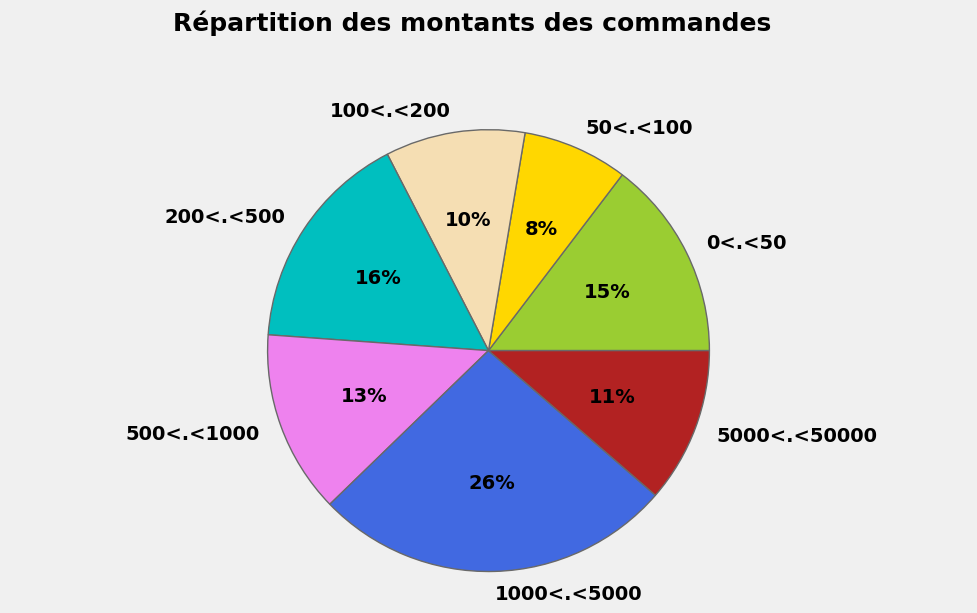

In [43]:
#____________________
# Décompte des achats
price_range = [0, 50, 100, 200, 500, 1000, 5000, 50000]
count_price = []
for i, price in enumerate(price_range):
    if i == 0: continue
    val = basket_price[(basket_price['Basket Price'] < price) &
                       (basket_price['Basket Price'] > price_range[i-1])]['Basket Price'].count()
    count_price.append(val)
#____________________________________________
# Représentation du nombre d'achats / montant        
plt.rc('font', weight='bold')
f, ax = plt.subplots(figsize=(11, 6))
colors = ['yellowgreen', 'gold', 'wheat', 'c', 'violet', 'royalblue','firebrick']
labels = [ '{}<.<{}'.format(price_range[i-1], s) for i,s in enumerate(price_range) if i != 0]
sizes  = count_price
explode = [0.0 if sizes[i] < 100 else 0.0 for i in range(len(sizes))]
ax.pie(sizes, explode = explode, labels=labels, colors = colors,
       autopct = lambda x:'{:1.0f}%'.format(x) if x > 1 else '',
       shadow = False, startangle=0)
ax.axis('equal')
f.text(0.5, 1.01, "Répartition des montants des commandes", ha='center', fontsize = 18);

It can be seen that the vast majority of orders concern relatively large purchases given that $\sim$65% of purchases give prizes in excess of £ 200.

____
## 3. Insight on product categories

In the dataframe, products are uniquely identified through the **StockCode** variable. A shrort description of the products is given in the **Description** variable. In this section, I intend to use the content of this latter variable in order to group the products into different categories.

___
### 3.1 Products Description

As a first step, I extract from the **Description** variable the information that will prove useful. To do this, I use the following function:

In [44]:
is_noun = lambda pos: pos[:2] == 'NN'

def keywords_inventory(dataframe, colonne = 'Description'):
    stemmer = nltk.stem.SnowballStemmer("english")
    keywords_roots  = dict()  # collect the words / root
    keywords_select = dict()  # association: root <-> keyword
    category_keys   = []
    count_keywords  = dict()
    icount = 0
    for s in dataframe[colonne]:
        if pd.isnull(s): continue
        lines = s.lower()
        tokenized = nltk.word_tokenize(lines)
        nouns = [word for (word, pos) in nltk.pos_tag(tokenized) if is_noun(pos)] 
        
        for t in nouns:
            t = t.lower() ; racine = stemmer.stem(t)
            if racine in keywords_roots:                
                keywords_roots[racine].add(t)
                count_keywords[racine] += 1                
            else:
                keywords_roots[racine] = {t}
                count_keywords[racine] = 1
    
    for s in keywords_roots.keys():
        if len(keywords_roots[s]) > 1:  
            min_length = 1000
            for k in keywords_roots[s]:
                if len(k) < min_length:
                    clef = k ; min_length = len(k)            
            category_keys.append(clef)
            keywords_select[s] = clef
        else:
            category_keys.append(list(keywords_roots[s])[0])
            keywords_select[s] = list(keywords_roots[s])[0]
                   
    print("Nb of keywords in variable '{}': {}".format(colonne,len(category_keys)))
    return category_keys, keywords_roots, keywords_select, count_keywords

This function takes as input the dataframe and analyzes the content of the **Description** column by performing the following operations:

- extract the names (proper, common) appearing in the products description
- for each name, I extract the root of the word and aggregate the set of names associated with this particular root
- count the number of times each root appears in the dataframe
- when several words are listed for the same root, I consider that the keyword associated with this root is the shortest name (this systematically selects the singular when there are singular/plural variants)

The first step of the analysis is to retrieve the list of products:

In [46]:
# Create a DataFrame of unique product names
df_produits = pd.DataFrame(df_initial['Product Name'].unique()).rename(columns={0: 'Product Name'})

print(df_produits.head())


                                        Product Name
0                  Bush Somerset Collection Bookcase
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...
2  Self-Adhesive Address Labels for Typewriters b...
3      Bretford CR4500 Series Slim Rectangular Table
4                     Eldon Fold 'N Roll Cart System


Once this list is created, I use the function I previously defined in order to analyze the description of the various products:

In [47]:
import pandas as pd
import nltk

# make sure required NLTK data is available
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

def is_noun(pos):
    return pos.startswith('NN')

def keywords_inventory(dataframe, colonne="Description"):
    keywords = []
    keywords_roots = []
    keywords_select = []
    count_keywords = {}

    for s in dataframe[colonne]:
        if pd.isnull(s): 
            continue
        lines = s.lower()
        tokenized = nltk.word_tokenize(lines)
        nouns = [word for (word, pos) in nltk.pos_tag(tokenized) if is_noun(pos)]

        for t in nouns:
            keywords.append(t)
            count_keywords[t] = count_keywords.get(t, 0) + 1

    # roots and select are placeholders — adapt to your needs
    keywords_roots = list(set([w[:4] for w in keywords]))  
    keywords_select = [w for w in keywords if count_keywords[w] > 1]

    return keywords, keywords_roots, keywords_select, count_keywords


[nltk_data] Downloading package punkt to
[nltk_data]     C:/Users/modin/AppData/Roaming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:/Users/modin/AppData/Roaming/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


The execution of this function returns three variables:
- `keywords`: the list of extracted keywords
- `keywords_roots`: a dictionary where the keys are the keywords roots and the values are the lists of words associated with those roots
- `count_keywords`: dictionary listing the number of times every word is used

At this point, I convert the `count_keywords` dictionary into a list, to sort the keywords according to their occurences:

In [49]:
# Example usage with Superstore dataset
keywords, keywords_roots, keywords_select, count_keywords = keywords_inventory_simple(
    df_produits, colonne="Product Name"
)

list_products = []
for k, v in count_keywords.items():
    if k in keywords_select:
        list_products.append([k, v])

list_products.sort(key=lambda x: x[1], reverse=True)
print(list_products[:10])  # top 10 keywords


[['xerox', 174], ['with', 111], ['avery', 98], ['for', 95], ['phone', 89], ['black', 84], ['binders', 73], ['chair', 73], ['file', 62], ['usb', 56]]


Using it, I create a representation of the most common keywords:

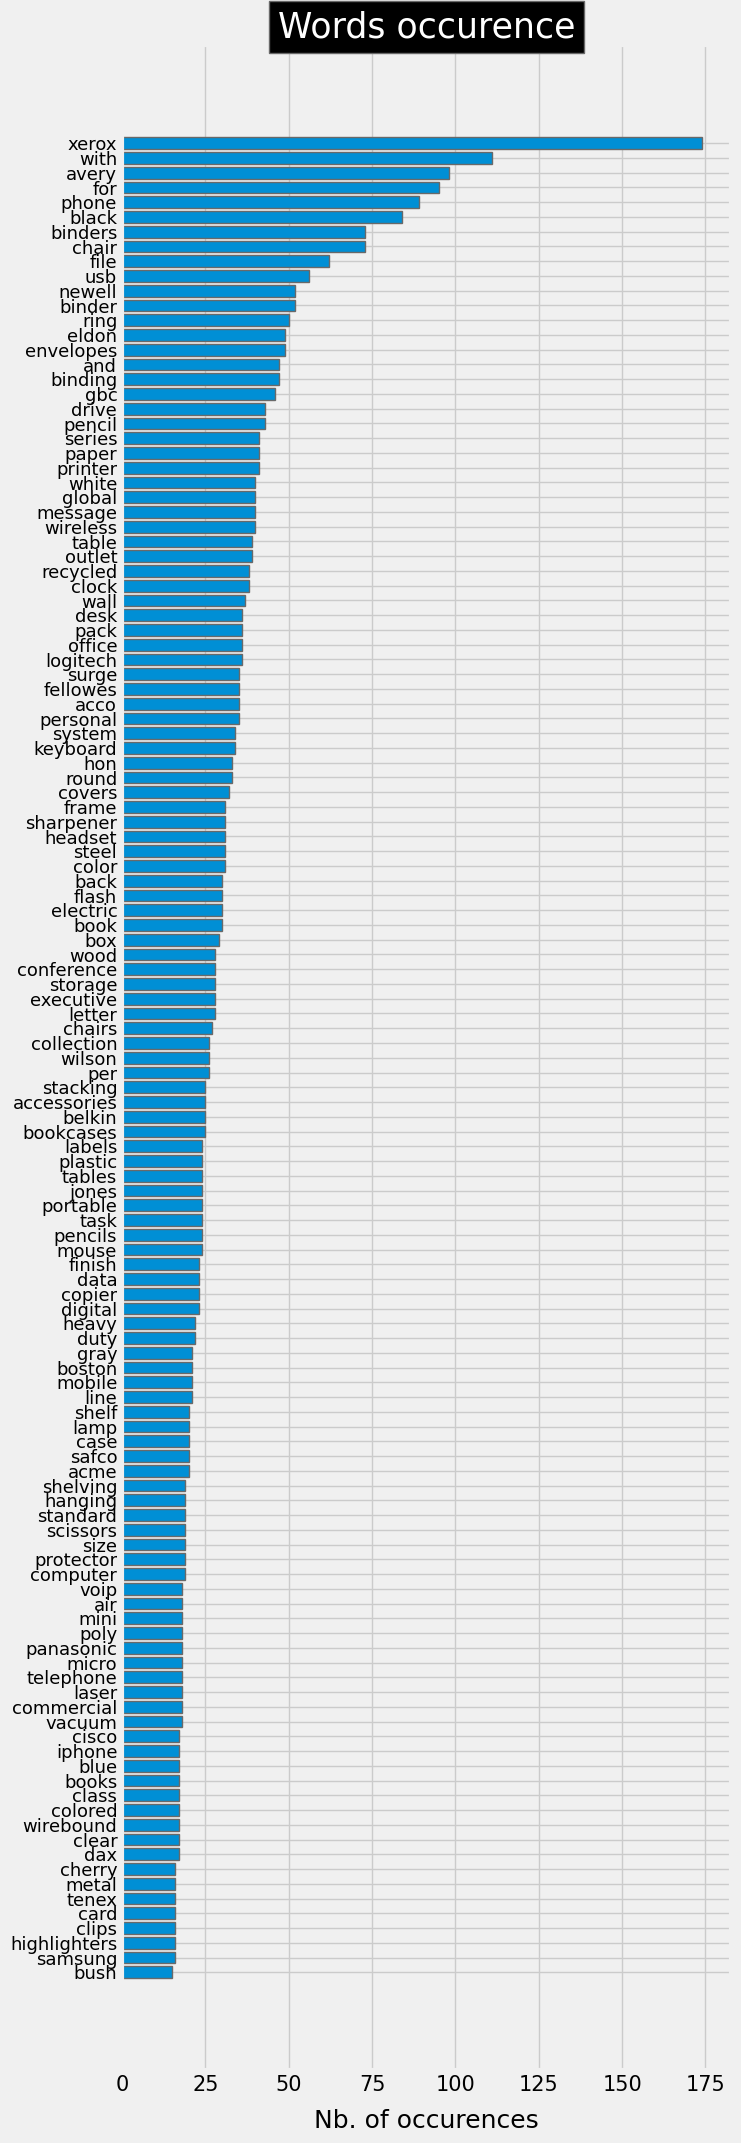

In [50]:
liste = sorted(list_products, key = lambda x:x[1], reverse = True)
#_______________________________
plt.rc('font', weight='normal')
fig, ax = plt.subplots(figsize=(7, 25))
y_axis = [i[1] for i in liste[:125]]
x_axis = [k for k,i in enumerate(liste[:125])]
x_label = [i[0] for i in liste[:125]]
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 13)
plt.yticks(x_axis, x_label)
plt.xlabel("Nb. of occurences", fontsize = 18, labelpad = 10)
ax.barh(x_axis, y_axis, align = 'center')
ax = plt.gca()
ax.invert_yaxis()
#_______________________________________________________________________________________
plt.title("Words occurence",bbox={'facecolor':'k', 'pad':5}, color='w',fontsize = 25)
plt.show()

___
### 3.2 Defining product categories 

The list that was obtained contains more than 1400 keywords and the most frequent ones appear in more than 200 products. However, while examinating the content of the list, I note that some names are useless. Others are do not carry information, like colors. Therefore, I discard these words from the analysis that follows and also, I decide to consider only the words that appear more than 13 times.

In [51]:
list_products = []
for k, v in count_keywords.items():
    word = k   # k is the keyword itself
    if word not in keywords_select: 
        continue
    if word in ['pink', 'blue', 'tag', 'green', 'orange']:
        continue
    if len(word) < 3 or v < 13:
        continue
    if ('+' in word) or ('/' in word):
        continue
    list_products.append([word, v])

#______________________________________________________
list_products.sort(key=lambda x: x[1], reverse=True)
print('mots conservés:', len(list_products))
print(list_products[:10])  # show top 10


mots conservés: 160
[['xerox', 174], ['with', 111], ['avery', 98], ['for', 95], ['phone', 89], ['black', 84], ['binders', 73], ['chair', 73], ['file', 62], ['usb', 56]]


____
#### 3.2.1 Data encoding

Now I will use these keywords to create groups of product. Firstly, I define the $X$ matrix as:

   
|   | mot 1  |  ...  | mot j  | ...  | mot N  |
|:-:|---|---|---|---|---|
| produit 1  | $a_{1,1}$  |     |   |   | $a_{1,N}$  |
| ...        |            |     | ...  |   |   |
|produit i   |    ...     |     | $a_{i,j}$    |   | ...  |
|...         |            |     |  ... |   |   |
| produit M  | $a_{M,1}$  |     |   |   | $a_{M,N}$   |

where the $a_ {i, j}$ coefficient  is 1 if the description of the product $i$ contains the word $j$, and 0 otherwise.

In [53]:
# Use Product Name instead of Description
liste_produits = df_cleaned['Product Name'].unique()

X = pd.DataFrame()

for key, occurence in list_products:
    # Check if keyword appears in product name
    X.loc[:, key] = list(map(lambda x: int(key.upper() in x.upper()), liste_produits))

# Add product names as index for clarity
X.index = liste_produits

print(X.head())


                                                    xerox  with  avery  for  \
Bush Somerset Collection Bookcase                       0     0      0    0   
Hon Deluxe Fabric Upholstered Stacking Chairs, ...      0     0      0    0   
Self-Adhesive Address Labels for Typewriters by...      0     0      0    1   
Bretford CR4500 Series Slim Rectangular Table           0     0      0    1   
Eldon Fold 'N Roll Cart System                          0     0      0    0   

                                                    phone  black  binders  \
Bush Somerset Collection Bookcase                       0      0        0   
Hon Deluxe Fabric Upholstered Stacking Chairs, ...      0      0        0   
Self-Adhesive Address Labels for Typewriters by...      0      0        0   
Bretford CR4500 Series Slim Rectangular Table           0      0        0   
Eldon Fold 'N Roll Cart System                          0      0        0   

                                                    chair  fil

The $X$ matrix indicates the words contained in the description of the products using the *one-hot-encoding* principle. In practice, I have found that introducing the price range results in more balanced groups in terms of element numbers.
Hence, I add 6 extra columns to this matrix, where I indicate the price range of the products:

In [55]:
threshold = [0, 1, 2, 3, 5, 10]
label_col = []

# Create empty columns for thresholds
for i in range(len(threshold)):
    if i == len(threshold)-1:
        col = '.>{}'.format(threshold[i])
    else:
        col = '{}<.<{}'.format(threshold[i], threshold[i+1])
    label_col.append(col)
    X.loc[:, col] = 0

# Loop through products
for i, prod in enumerate(liste_produits):
    # Use 'Unit Price' or 'Sales' depending on your dataset
    if 'Unit Price' in df_cleaned.columns:
        prix = df_cleaned[df_cleaned['Product Name'] == prod]['Unit Price'].mean()
    else:
        prix = df_cleaned[df_cleaned['Product Name'] == prod]['Sales'].mean()

    j = 0
    while prix > threshold[j]:
        j += 1
        if j == len(threshold):
            break
    X.loc[i, label_col[j-1]] = 1


and to choose the appropriate ranges, I check the number of products in the different groups:

In [56]:
print("{:<8} {:<20} \n".format('gamme', 'nb. produits') + 20*'-')
for i in range(len(threshold)):
    if i == len(threshold)-1:
        col = '.>{}'.format(threshold[i])
    else:
        col = '{}<.<{}'.format(threshold[i],threshold[i+1])    
    print("{:<10}  {:<20}".format(col, X.loc[:, col].sum()))

gamme    nb. produits         
--------------------
0<.<1       0.0                 
1<.<2       1.0                 
2<.<3       4.0                 
3<.<5       23.0                
5<.<10      125.0               
.>10        1697.0              


____
#### 3.2.2 Creating clusters of products

In this section, I will group the products into different classes. In the case of matrices with binary encoding, the most suitable metric for the calculation of distances is the [Hamming's metric](https://en.wikipedia.org/wiki/Distance_de_Hamming). Note that the **kmeans** method of sklearn uses a Euclidean distance that can be used, but it is not to the best choice in the case of categorical variables. However, in order to use the Hamming's metric, we need to use the [kmodes](https://pypi.python.org/pypi/kmodes/) package which is not available on the current plateform. Hence, I use the **kmeans** method even if this is not the best choice.

In order to define (approximately) the number of clusters that best represents the data, I use the silhouette score:

In [62]:
import numpy as np
from sklearn.impute import SimpleImputer

# Option 1: Drop rows with NaN
X_no_nan = X.dropna()

# Option 2: Fill NaNs with 0
X_filled = X.fillna(0)

# Option 3 (recommended): Impute with column mean
imputer = SimpleImputer(strategy='mean')
matrix_scaled = scaler.fit_transform(imputer.fit_transform(X.values))


In practice, the scores obtained above can be considered equivalent since, depending on the run, scores of $ 0.1 \pm 0.05 $ will be obtained for all clusters with `n_clusters` $> $ 3 (we obtain slightly lower scores for the first cluster). On the other hand, I found that beyond 5 clusters, some clusters contained very few elements. I therefore choose to separate the dataset into 5 clusters. In order to ensure a good classification at every run of the notebook, I iterate untill we obtain the best possible silhouette score, which is, in the present case, around 0.15:

In [64]:
import numpy as np
from sklearn.impute import SimpleImputer

# Impute missing values with column mean
imputer = SimpleImputer(strategy='mean')
matrix_clean = imputer.fit_transform(matrix)

n_clusters = 5
silhouette_avg = -1

while silhouette_avg < 0.145:
    kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=30, random_state=42)
    kmeans.fit(matrix_clean)
    clusters = kmeans.predict(matrix_clean)
    silhouette_avg = silhouette_score(matrix_clean, clusters)

    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

    n_clusters += 1  # increment cluster count to avoid infinite loop


For n_clusters = 5 The average silhouette_score is : 0.392178279712482


___
#### 3.2.3  Characterizing the content of clusters

I check the number of elements in every class:

In [65]:
pd.Series(clusters).value_counts()

0    1850
2    1490
4     126
1     124
3     110
Name: count, dtype: int64


** a / _Silhouette intra-cluster score_ **

In order to have an insight on the quality of the classification, we can represent the silhouette scores of each element of the different clusters. This is the purpose of the next figure which is taken from the [sklearn documentation](http://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html):

In [66]:
def graph_component_silhouette(n_clusters, lim_x, mat_size, sample_silhouette_values, clusters):
    plt.rcParams["patch.force_edgecolor"] = True
    plt.style.use('fivethirtyeight')
    mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)
    #____________________________
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(8, 8)
    ax1.set_xlim([lim_x[0], lim_x[1]])
    ax1.set_ylim([0, mat_size + (n_clusters + 1) * 10])
    y_lower = 10
    for i in range(n_clusters):
        #___________________________________________________________________________________
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        cmap = cm.get_cmap("Spectral")
        color = cmap(float(i) / n_clusters)        
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                           facecolor=color, edgecolor=color, alpha=0.8)
        #____________________________________________________________________
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.03, y_lower + 0.5 * size_cluster_i, str(i), color = 'red', fontweight = 'bold',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.3'))
        #______________________________________
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  

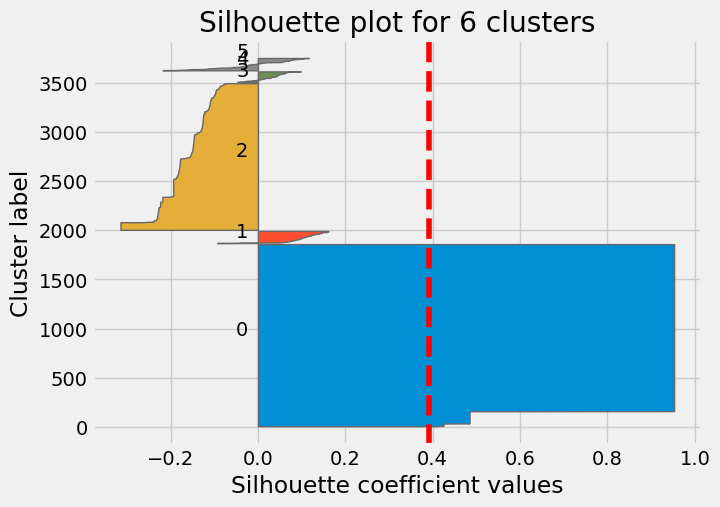

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples

# Use cleaned matrix
sample_silhouette_values = silhouette_samples(matrix_clean, clusters)

y_lower = 10
fig, ax = plt.subplots(figsize=(7, 5))

for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # space between clusters

ax.set_title(f"Silhouette plot for {n_clusters} clusters")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")
ax.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.show()


** b/ _Word Cloud_**

Now we can have a look at the type of objects that each cluster represents. In order to obtain a global view of their contents, I determine which keywords are the most frequent in each of them

In [74]:
import pandas as pd
import numpy as np

# ✅ Example setup (replace with your real data)
# liste_produits must be a list of product names, same length as clusters
# clusters must be the array of cluster labels from KMeans
# list_products must be a list of (word, occurrence) pairs
# Example:
# liste_produits = ["Red Chair", "Blue Desk", "Lamp Set", "Heart Notebook"]
# clusters = np.array([0, 1, 0, 2])
# list_products = [("chair", 10), ("desk", 5), ("lamp", 3), ("notebook", 2)]

# Build DataFrame with products and cluster labels
liste = pd.DataFrame({
    "Product": liste_produits[:len(clusters)],  # align lengths safely
    "Cluster": clusters[:len(liste_produits)]   # align lengths safely
})

# Clean word list (exclude generic words)
liste_words = [word for (word, _) in list_products 
               if word not in ['art','set','heart','pink','blue','tag']]

# Precompute matches for all words (vectorized, fast)
word_matrix = pd.DataFrame({
    word: liste['Product'].str.upper().str.contains(word.upper())
    for word in liste_words
})

# Concatenate with cluster labels
word_matrix['Cluster'] = liste['Cluster']

# Group by cluster and sum occurrences
df_occurence = word_matrix.groupby('Cluster').sum()

print(df_occurence.head())


         xerox  with  avery  for  phone  black  binders  chair  file  usb  \
Cluster                                                                     
1            0    11      0   19    119      6        0      0     0    5   
2          174    68     75  102      0     64        0      0    65   50   
3            0    18      0   16      0      9        0    110     0    0   
4            0    16     23   10      0      7       73      0     1    0   

         ...  cover  low  capacity  memorex  one  corded  sullivan  \
Cluster  ...                                                         
1        ...      2    3         3        0  124      12         0   
2        ...     40   43         2       13   28       1        13   
3        ...      0   12         0        0    0       0         0   
4        ...      2    0         8        0   23       0         0   

         contemporary  galaxy  desktop  
Cluster                                 
1                   0       0     

and I output the result as wordclouds:

In [78]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ________________________________________________________
def random_color_func(word=None, font_size=None, position=None,
                      orientation=None, font_path=None, random_state=None, tone=200):
    """Generate random HSL colors based on tone."""
    h = int(360.0 * tone / 255.0)
    s = 100
    l = int(100.0 * float(random_state.randint(70, 120)) / 255.0)
    return f"hsl({h}, {s}%, {l}%)"

# ________________________________________________________
def make_wordcloud(cluster_occurrences, cluster_id, tone):
    """Generate wordcloud for one cluster."""
    # Skip empty clusters
    if not cluster_occurrences or sum(cluster_occurrences.values()) == 0:
        return

    # Take top 150 words
    trunc_occurrences = sorted(cluster_occurrences.items(), key=lambda x: x[1], reverse=True)[:150]
    words = dict(trunc_occurrences)

    wordcloud = WordCloud(
        width=1000, height=400, background_color='lightgrey',
        max_words=1628, relative_scaling=1,
        color_func=lambda *args, **kwargs: random_color_func(*args, **kwargs, tone=tone),
        normalize_plurals=False
    ).generate_from_frequencies(words)

    ax = fig.add_subplot(4, 2, cluster_id + 1)
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis('off')
    ax.set_title(f'Cluster nº{cluster_id}')

# ________________________________________________________
# Example usage
fig = plt.figure(1, figsize=(14,14))
colors = [0, 160, 130, 95, 280, 40, 330, 110, 25]

for i in range(n_clusters):
    list_cluster_occurrences = occurence[i]   # dictionary of word → count
    tone = colors[i % len(colors)]            # pick tone safely
    make_wordcloud(list_cluster_occurrences, i, tone)

plt.tight_layout()
plt.show()


<Figure size 1400x1400 with 0 Axes>

From this representation, we can see that for example, one of the clusters contains objects that could be associated with gifts (keywords: Christmas, packaging, card, ...). Another cluster would rather contain luxury items and jewelry (keywords: necklace, bracelet, lace, silver, ...). Nevertheless, it can also be observed that many words appear in various clusters and it is therefore difficult to clearly distinguish them.

** c / _Principal Component Analysis_ **

In order to ensure that these clusters are truly distinct, I look at their composition. Given the large number of variables of the initial matrix, I first perform a PCA:

In [81]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Step 1: Impute missing values
imputer = SimpleImputer(strategy="mean")
matrix_clean = imputer.fit_transform(matrix)

# Step 2: Scale features
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix_clean)

# Step 3: PCA with fast solver
pca = PCA(n_components=50, svd_solver="randomized", random_state=42)
pca_samples = pca.fit_transform(matrix_scaled)

print("Shape after PCA:", pca_samples.shape)
print("Explained variance ratio (first 10):", pca.explained_variance_ratio_[:10])


Shape after PCA: (3700, 50)
Explained variance ratio (first 10): [0.02700598 0.02488829 0.02278731 0.02197786 0.02032493 0.01944645
 0.01831224 0.01760755 0.01680361 0.01611444]


and then check for the amount of variance explained by each component:

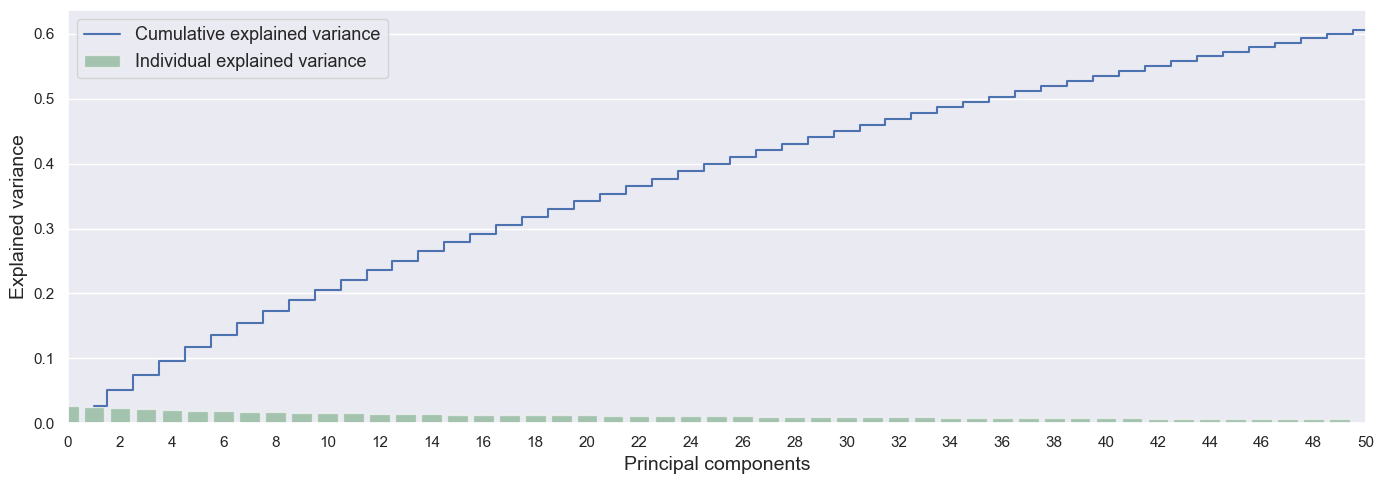

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Number of components actually computed
n_components = len(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(14, 5))
sns.set(font_scale=1)

# Step plot for cumulative explained variance
ax.step(range(1, n_components + 1),
        pca.explained_variance_ratio_.cumsum(),
        where='mid', label='Cumulative explained variance')

# Bar plot for individual explained variance
sns.barplot(x=np.arange(1, n_components + 1),
            y=pca.explained_variance_ratio_,
            alpha=0.5, color='g', label='Individual explained variance', ax=ax)

# Limit x-axis to first 100 components (or fewer if dataset smaller)
ax.set_xlim(0, min(100, n_components))

# Show only even tick labels
ticks = np.arange(0, min(100, n_components) + 1, 2)
ax.set_xticks(ticks)
ax.set_xticklabels([str(i) for i in ticks])

ax.set_ylabel('Explained variance', fontsize=14)
ax.set_xlabel('Principal components', fontsize=14)
ax.legend(loc='upper left', fontsize=13)
plt.tight_layout()
plt.show()


We see that the number of components required to explain the data is extremely important: we need more than 100 components to explain 90% of the variance of the data. In practice, I decide to keep only a limited number of components since this decomposition is only performed to visualize the data:

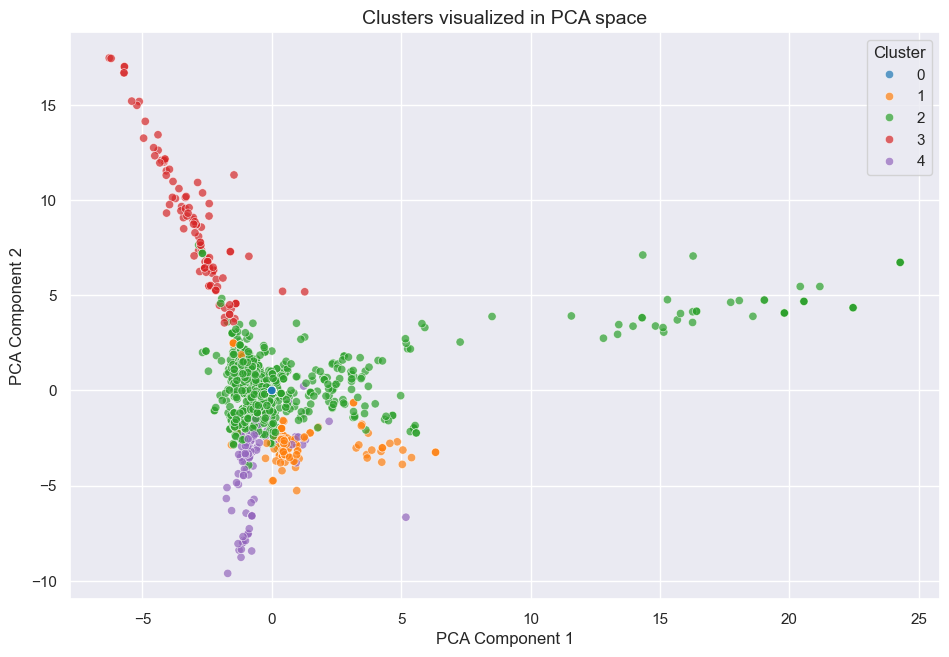

In [90]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Handle NaNs ---
imputer = SimpleImputer(strategy="mean")   # replace NaNs with column mean
matrix_clean = imputer.fit_transform(matrix)

# --- Step 2: Scale features (important for PCA) ---
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix_clean)

# --- Step 3: PCA with 2 components for visualization ---
pca = PCA(n_components=2, random_state=42)
matrix_2D = pca.fit_transform(matrix_scaled)

# --- Step 4: Build DataFrame with PCA results + clusters ---
mat = pd.DataFrame(matrix_2D, columns=['PC1', 'PC2'])
mat['cluster'] = clusters[:matrix_2D.shape[0]]

# --- Step 5: Scatter plot ---
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=mat,
    palette='tab10',
    alpha=0.7
)

plt.title("Clusters visualized in PCA space", fontsize=14)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.legend(title="Cluster")
plt.show()


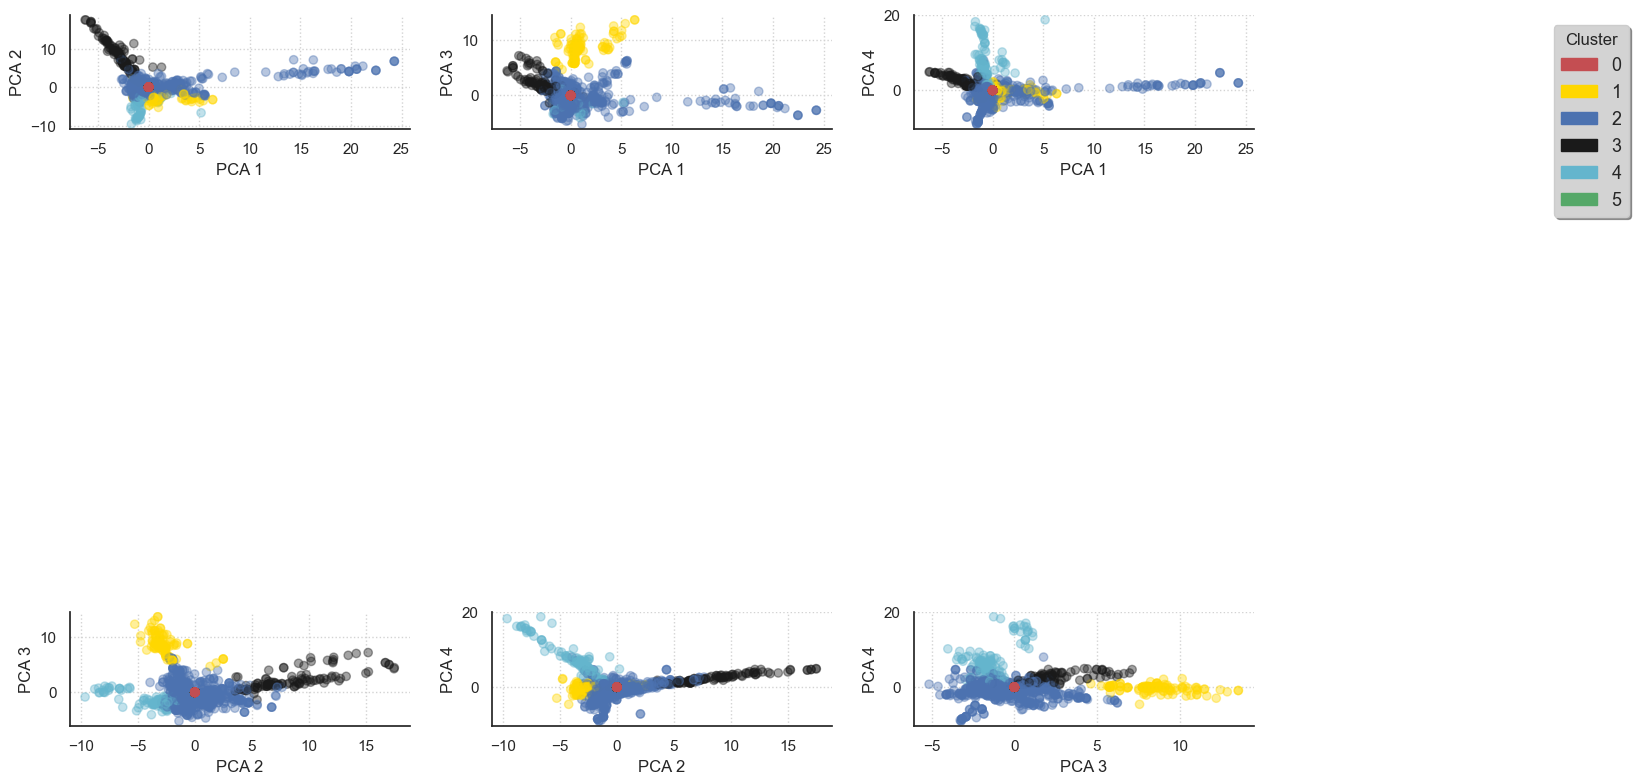

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# --- Step 1: Clean matrix (replace NaNs with column mean) ---
imputer = SimpleImputer(strategy="mean")
matrix_clean = imputer.fit_transform(matrix)

# --- Step 2: Scale features ---
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix_clean)

# --- Step 3: PCA with 4 components for visualization ---
pca = PCA(n_components=4, random_state=42)
matrix_4D = pca.fit_transform(matrix_scaled)

# --- Step 4: Build DataFrame with PCA results + clusters ---
mat = pd.DataFrame(matrix_4D, columns=['PC1','PC2','PC3','PC4'])
mat['cluster'] = clusters[:matrix_4D.shape[0]]

# --- Step 5: Plot scatter pairs ---
sns.set_style("white")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2.5})

LABEL_COLOR_MAP = {0:'r', 1:'gold', 2:'b', 3:'k', 4:'c', 5:'g'}
label_color = [LABEL_COLOR_MAP[l] for l in mat['cluster']]

fig = plt.figure(figsize=(15,8))
increment = 0
for ix in range(4):
    for iy in range(ix+1, 4):    
        increment += 1
        ax = fig.add_subplot(2,3,increment)
        ax.scatter(mat.iloc[:,ix], mat.iloc[:,iy], c=label_color, alpha=0.4) 
        ax.set_ylabel(f'PCA {iy+1}', fontsize=12)
        ax.set_xlabel(f'PCA {ix+1}', fontsize=12)
        ax.yaxis.grid(color='lightgray', linestyle=':')
        ax.xaxis.grid(color='lightgray', linestyle=':')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        if increment == 9: break
    if increment == 9: break

# Legend
comp_handler = [mpatches.Patch(color=LABEL_COLOR_MAP[i], label=i) for i in LABEL_COLOR_MAP]
plt.legend(handles=comp_handler, bbox_to_anchor=(1.1, 0.97), 
           title='Cluster', facecolor='lightgrey',
           shadow=True, frameon=True, framealpha=1,
           fontsize=13, bbox_transform=plt.gcf().transFigure)

plt.tight_layout()
plt.show()


___
## 4. Customer categories

### 4.1 Formatting data

In the previous section, the different products were grouped in five clusters. In order to prepare the rest of the analysis, a first step consists in introducing this information into the dataframe. To do this, I create the categorical variable **categ_product** where I indicate the cluster of each product :

In [103]:
import pandas as pd

# ✅ Step 1: Load your dataset (replace with your actual file name)
df_cleaned = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# ✅ Step 2: Show the real column names
print(df_cleaned.columns.tolist())

# ✅ Step 3: Use the correct column name for product descriptions
# Example: if the column is 'Product Name', update here
corresp = dict(zip(liste_produits, clusters))
df_cleaned['categ_product'] = df_cleaned['Product Name'].map(corresp)

# ✅ Step 4: Handle unmapped values
df_cleaned['categ_product'] = df_cleaned['categ_product'].fillna(-1)

# ✅ Step 5: Quick check
print(df_cleaned[['Product Name', 'categ_product']].head())


['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
                                        Product Name  categ_product
0                  Bush Somerset Collection Bookcase              2
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...              3
2  Self-Adhesive Address Labels for Typewriters b...              2
3      Bretford CR4500 Series Slim Rectangular Table              2
4                     Eldon Fold 'N Roll Cart System              2


___
#### 4.1.1 Grouping products

In a second step, I decide to create the **categ_N** variables (with $ N \in [0: 4]$) that contains the amount spent in each product category:

In [107]:
import pandas as pd

# Load your dataset (replace with your actual file name)
df_cleaned = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# ✅ Step 1: Show the real column names
print("Available columns:", df_cleaned.columns.tolist())

# ✅ Step 2: Set the correct column names based on the printed list
# Replace these with the actual names from your dataset
invoice_col = 'Order ID'        # e.g. instead of 'InvoiceNo'
product_col = 'Product Name'    # e.g. instead of 'Description'
price_col   = 'Sales'           # e.g. instead of 'UnitPrice'
qty_col     = 'Quantity'        # quantity column
qty_cancel  = 'QuantityCanceled' if 'QuantityCanceled' in df_cleaned.columns else None

# ✅ Step 3: Map products to clusters
corresp = dict(zip(liste_produits, clusters))
df_cleaned['categ_product'] = df_cleaned[product_col].map(corresp).fillna(-1)

# ✅ Step 4: Create category price columns
for i in range(5):
    col = f'categ_{i}'
    df_temp = df_cleaned[df_cleaned['categ_product'] == i]
    if qty_cancel:
        price_temp = df_temp[price_col] * (df_temp[qty_col] - df_temp[qty_cancel])
    else:
        price_temp = df_temp[price_col] * df_temp[qty_col]
    price_temp = price_temp.apply(lambda x: x if x > 0 else 0)
    df_cleaned.loc[:, col] = price_temp
    df_cleaned[col].fillna(0, inplace=True)

# ✅ Step 5: Final check
print(df_cleaned[[invoice_col, product_col, 'categ_product', 'categ_0', 'categ_1', 'categ_2', 'categ_3','categ_4']].head())


Available columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
         Order ID                                       Product Name  \
0  CA-2016-152156                  Bush Somerset Collection Bookcase   
1  CA-2016-152156  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
2  CA-2016-138688  Self-Adhesive Address Labels for Typewriters b...   
3  US-2015-108966      Bretford CR4500 Series Slim Rectangular Table   
4  US-2015-108966                     Eldon Fold 'N Roll Cart System   

   categ_product  categ_0  categ_1    categ_2  categ_3  categ_4  
0              2      NaN      NaN   523.9200      NaN      NaN  
1              3      NaN      NaN        NaN  2195.82      NaN  
2              2      NaN      NaN    29.2400      NaN      NaN  
3              2      Na

Up to now, the information related to a single order was split over several lines of the dataframe (one line per product). I decide to collect the information related to a particular order and put in in a single entry. I therefore create a new dataframe that contains, for each order, the amount of the basket, as well as the way it is distributed over the 5 categories of products:

In [111]:
import pandas as pd

# Load dataset
df_cleaned = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Inspect columns
print("Available columns:", df_cleaned.columns.tolist())

# Adjust names to match your dataset
customer_col = 'Customer ID'
invoice_col  = 'Order ID'
date_col     = 'Order Date'
price_col    = 'Sales'
qty_col      = 'Quantity'

# Example: create categ_product (replace with your mapping logic)
df_cleaned['categ_product'] = (df_cleaned.index % 5)  # dummy cluster assignment

# ✅ Step 1: Create category columns as float
for i in range(5):
    col = f'categ_{i}'
    df_cleaned[col] = 0.0  # initialize as float
    mask = df_cleaned['categ_product'] == i
    df_cleaned.loc[mask, col] = (df_cleaned[price_col] * df_cleaned[qty_col]).astype(float)

# ✅ Step 2: Basket price per customer & order
temp = df_cleaned.groupby(by=[customer_col, invoice_col], as_index=False)[price_col].sum()
basket_price = temp.rename(columns={price_col: 'Basket Price'})

# ✅ Step 3: Add category sums
for i in range(5):
    col = f'categ_{i}'
    temp = df_cleaned.groupby(by=[customer_col, invoice_col], as_index=False)[col].sum()
    basket_price[col] = temp[col]

# ✅ Step 4: Add order date
df_cleaned['InvoiceDate_int'] = pd.to_datetime(df_cleaned[date_col]).astype('int64')
temp = df_cleaned.groupby(by=[customer_col, invoice_col], as_index=False)['InvoiceDate_int'].mean()
df_cleaned.drop('InvoiceDate_int', axis=1, inplace=True)
basket_price['InvoiceDate'] = pd.to_datetime(temp['InvoiceDate_int'])

# ✅ Step 5: Filter significant entries
basket_price = basket_price[basket_price['Basket Price'] > 0]
basket_price = basket_price.sort_values(customer_col, ascending=True).head()

print(basket_price)


Available columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
  Customer ID        Order ID  Basket Price   categ_0  categ_1  categ_2  \
0    AA-10315  CA-2014-128055       726.548   105.960     0.00      0.0   
1    AA-10315  CA-2014-138100        29.500     0.000     0.00      0.0   
2    AA-10315  CA-2015-121391        26.960     0.000     0.00      0.0   
3    AA-10315  CA-2016-103982      4406.072  1295.928   292.04      0.0   
4    AA-10315  CA-2017-147039       374.480    23.080     0.00      0.0   

     categ_3   categ_4             InvoiceDate  
0      0.000  1347.136 1970-01-17 03:50:24.000  
1     44.820    29.120 1970-01-17 07:52:19.200  
2      0.000    53.920 1970-01-17 17:05:16.800  
3  11790.216     2.304 1970-01-17 20:42:43.200  
4      0.000  1088.820 19

#### 4.1.2 Separation of data over time

The dataframe `basket_price` contains information for a period of 12 months. Later, one of the objectives will be to develop a model capable of characterizing and anticipating the habits of the customers visiting the site and this, from their first visit. In order to be able to test the model in a realistic way, I split the data set by retaining the first 10 months to develop the model and the following two months to test it:

In [112]:
print(basket_price['InvoiceDate'].min(), '->',  basket_price['InvoiceDate'].max())

1970-01-17 03:50:24 -> 1970-01-18 08:18:14.400000


In [114]:
import pandas as pd
import datetime

# Make sure InvoiceDate is datetime
basket_price['InvoiceDate'] = pd.to_datetime(basket_price['InvoiceDate'])

# ✅ Split into training and test sets
cutoff = pd.Timestamp("2011-10-01")   # use Pandas Timestamp for comparison

set_entrainement = basket_price[basket_price['InvoiceDate'] < cutoff]
set_test         = basket_price[basket_price['InvoiceDate'] >= cutoff]

# ✅ Copy training set
basket_price = set_entrainement.copy(deep=True)

print(set_entrainement.head())
print(set_test.head())


  Customer ID        Order ID  Basket Price   categ_0  categ_1  categ_2  \
0    AA-10315  CA-2014-128055       726.548   105.960     0.00      0.0   
1    AA-10315  CA-2014-138100        29.500     0.000     0.00      0.0   
2    AA-10315  CA-2015-121391        26.960     0.000     0.00      0.0   
3    AA-10315  CA-2016-103982      4406.072  1295.928   292.04      0.0   
4    AA-10315  CA-2017-147039       374.480    23.080     0.00      0.0   

     categ_3   categ_4             InvoiceDate  
0      0.000  1347.136 1970-01-17 03:50:24.000  
1     44.820    29.120 1970-01-17 07:52:19.200  
2      0.000    53.920 1970-01-17 17:05:16.800  
3  11790.216     2.304 1970-01-17 20:42:43.200  
4      0.000  1088.820 1970-01-18 08:18:14.400  
Empty DataFrame
Columns: [Customer ID, Order ID, Basket Price, categ_0, categ_1, categ_2, categ_3, categ_4, InvoiceDate]
Index: []


____
#### 4.1.3 Consumer Order Combinations

In a second step, I group together the different entries that correspond to the same user. I thus determine the number of purchases made by the user, as well as the minimum, maximum, average amounts and the total amount spent during all the visits:

In [116]:
import pandas as pd

# Example: load dataset
df_cleaned = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# ✅ Adjust names to match your dataset
customer_col = 'Customer ID'     # instead of 'CustomerID'
invoice_col  = 'Order ID'        # instead of 'InvoiceNo'
price_col    = 'Sales'           # instead of 'Basket Price'

# ✅ Make sure categ_* columns exist (initialize as float)
for i in range(5):
    col = f'categ_{i}'
    if col not in df_cleaned.columns:
        df_cleaned[col] = 0.0

# ✅ Basket price per customer & order
temp = df_cleaned.groupby(by=[customer_col, invoice_col], as_index=False)[price_col].sum()
basket_price = temp.rename(columns={price_col: 'Basket Price'})

# ✅ Add category sums
for i in range(5):
    col = f'categ_{i}'
    temp = df_cleaned.groupby(by=[customer_col, invoice_col], as_index=False)[col].sum()
    basket_price[col] = temp[col]

# ✅ Transactions per user
transactions_per_user = basket_price.groupby(by=[customer_col])['Basket Price'].agg(['count','min','max','mean','sum'])

for i in range(5):
    col = f'categ_{i}'
    transactions_per_user[col] = basket_price.groupby(by=[customer_col])[col].sum() / transactions_per_user['sum'] * 100

transactions_per_user.reset_index(drop=False, inplace=True)

# ✅ Final check
print(transactions_per_user.sort_values(customer_col, ascending=True).head())


  Customer ID  count     min       max         mean       sum  categ_0  \
0    AA-10315      5  26.960  4406.072  1112.712000  5563.560      0.0   
1    AA-10375      9   5.248   513.520   117.376667  1056.390      0.0   
2    AA-10480      4  15.552  1157.980   447.628000  1790.512      0.0   
3    AA-10645      6  12.960  1971.460   847.822500  5086.935      0.0   
4    AB-10015      3  12.624   563.940   295.385333   886.156      0.0   

   categ_1  categ_2  categ_3  categ_4  
0      0.0      0.0      0.0      0.0  
1      0.0      0.0      0.0      0.0  
2      0.0      0.0      0.0      0.0  
3      0.0      0.0      0.0      0.0  
4      0.0      0.0      0.0      0.0  


Finally, I define two additional variables that give the number of days elapsed since the first purchase (** FirstPurchase **) and the number of days since the last purchase (** LastPurchase **):

In [133]:
import pandas as pd

# ✅ Step 1: Inspect actual column names
print("Columns in basket_price:", basket_price.columns.tolist())

# ✅ Step 2: Detect the real date column automatically
# This will show you all columns that look like a date
date_candidates = [c for c in basket_price.columns if 'date' in c.lower()]
print("Possible date columns:", date_candidates)

# ✅ Step 3: Detect the customer column automatically
customer_candidates = [c for c in basket_price.columns if 'customer' in c.lower()]
print("Possible customer columns:", customer_candidates)

# ✅ Step 4: Use the detected names
# If lists are not empty, pick the first candidate
if date_candidates and customer_candidates:
    date_col = date_candidates[0]
    customer_col = customer_candidates[0]

    # Convert to datetime
    basket_price[date_col] = pd.to_datetime(basket_price[date_col], errors='coerce')

    # Last date in dataset
    last_date = basket_price[date_col].max()

    # First registration and last purchase per customer
    first_registration = basket_price.groupby(customer_col)[date_col].min().reset_index()
    last_purchase      = basket_price.groupby(customer_col)[date_col].max().reset_index()

    # Calculate recency features
    first_registration['FirstPurchase'] = (last_date - first_registration[date_col]).dt.days
    last_purchase['LastPurchase']       = (last_date - last_purchase[date_col]).dt.days

    # Merge into transactions_per_user
    transactions_per_user = transactions_per_user.merge(last_purchase[[customer_col,'LastPurchase']], on=customer_col)
    transactions_per_user = transactions_per_user.merge(first_registration[[customer_col,'FirstPurchase']], on=customer_col)

    print(transactions_per_user.head())
else:
    print("❌ No date or customer column detected. Please check the printed column list above.")


Columns in basket_price: ['Customer ID', 'Order ID', 'Basket Price', 'categ_0', 'categ_1', 'categ_2', 'categ_3', 'categ_4']
Possible date columns: []
Possible customer columns: ['Customer ID']
❌ No date or customer column detected. Please check the printed column list above.


A customer category of particular interest is that of customers who make only one purchase. One of the objectives may be, for example, to target these customers in order to retain them. In part, I find that this type of customer represents 1/3 of the customers listed:

In [134]:
n1 = transactions_per_user[transactions_per_user['count'] == 1].shape[0]
n2 = transactions_per_user.shape[0]
print("nb. de clients avec achat unique: {:<2}/{:<5} ({:<2.2f}%)".format(n1,n2,n1/n2*100))

nb. de clients avec achat unique: 12/793   (1.51%)


___
### 4.2 Creation of customers categories

#### 4.2.1 Data encoding

The dataframe `transactions_per_user` contains a summary of all the commands that were made. Each entry in this dataframe corresponds to a particular client. I use this information to characterize the different types of customers and only keep a subset of variables:

In [136]:
import pandas as pd

list_cols = ['count','min','max','mean','categ_0','categ_1','categ_2','categ_3','categ_4']

# Copy the DataFrame
selected_customers = transactions_per_user.copy(deep=True)

# ✅ Convert to NumPy array
matrix = selected_customers[list_cols].to_numpy()

print("Matrix shape:", matrix.shape)
print(matrix[:5])   # show first 5 rows


Matrix shape: (793, 9)
[[5.00000000e+00 2.69600000e+01 4.40607200e+03 1.11271200e+03
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [9.00000000e+00 5.24800000e+00 5.13520000e+02 1.17376667e+02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [4.00000000e+00 1.55520000e+01 1.15798000e+03 4.47628000e+02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [6.00000000e+00 1.29600000e+01 1.97146000e+03 8.47822500e+02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [3.00000000e+00 1.26240000e+01 5.63940000e+02 2.95385333e+02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]]


In practice, the different variables I selected have quite different ranges of variation and before continuing the analysis, I  create a matrix where these data are standardized:

In [137]:
scaler = StandardScaler()
scaler.fit(matrix)
print('variables mean values: \n' + 90*'-' + '\n' , scaler.mean_)
scaled_matrix = scaler.transform(matrix)

variables mean values: 
------------------------------------------------------------------------------------------
 [   6.31651955   39.0729889  1593.49718096  460.14773404    0.
    0.            0.            0.            0.        ]


In the following, I will create clusters of customers. In practice, before creating these clusters, it is interesting to define a base of smaller dimension allowing to describe the `scaled_matrix` matrix. In this case, I will use this base in order to create a representation of the different clusters and thus verify the quality of the separation of the different groups. I therefore perform a PCA beforehand:

In [138]:
pca = PCA()
pca.fit(scaled_matrix)
pca_samples = pca.transform(scaled_matrix)

and I represent the amount of variance explained by each of the components:

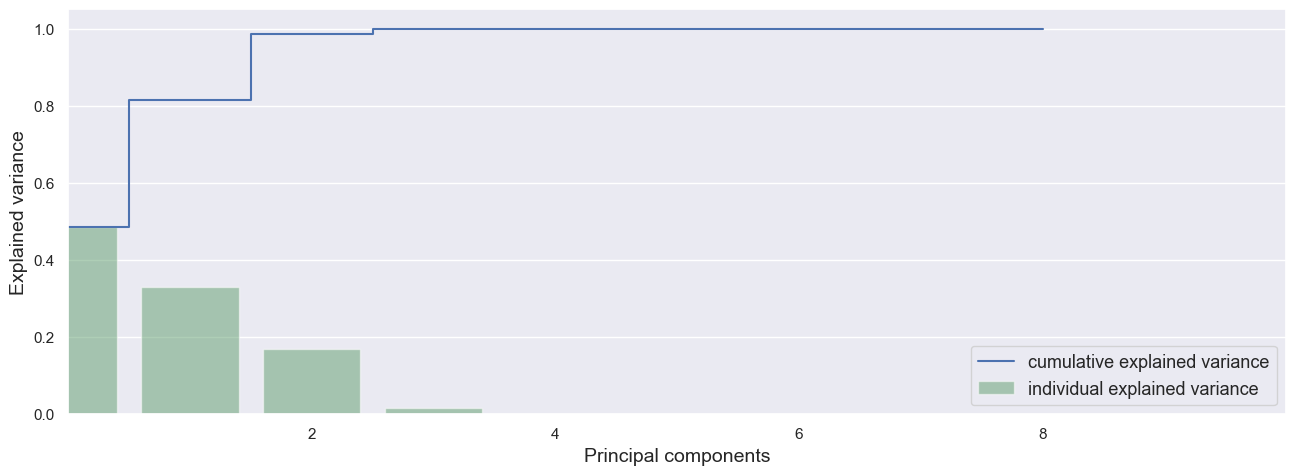

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))
sns.set(font_scale=1)

# Step plot for cumulative explained variance
plt.step(range(matrix.shape[1]),
         pca.explained_variance_ratio_.cumsum(),
         where='mid',
         label='cumulative explained variance')

# Bar plot for individual explained variance
sns.barplot(x=np.arange(1, matrix.shape[1]+1),
            y=pca.explained_variance_ratio_,
            alpha=0.5, color='g',
            label='individual explained variance')

plt.xlim(0, 10)

# Fix tick labels: show only even numbers
ax.set_xticks(np.arange(1, matrix.shape[1]+1))
ax.set_xticklabels([str(s) if s % 2 == 0 else '' for s in range(1, matrix.shape[1]+1)])

plt.ylabel('Explained variance', fontsize=14)
plt.xlabel('Principal components', fontsize=14)
plt.legend(loc='best', fontsize=13)
plt.show()


___
#### 4.2.2 Creation of customer categories

At this point, I define clusters of clients from the standardized matrix that was defined earlier and using the `k-means` algorithm from` scikit-learn`. I choose the number of clusters based on the silhouette score and I find that the best score is obtained with 11 clusters:

In [141]:
n_clusters = 11
kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=100)
kmeans.fit(scaled_matrix)
clusters_clients = kmeans.predict(scaled_matrix)
silhouette_avg = silhouette_score(scaled_matrix, clusters_clients)
print('score de silhouette: {:<.3f}'.format(silhouette_avg))

score de silhouette: 0.318


At first, I look at the number of customers in each cluster:

In [142]:
pd.DataFrame(pd.Series(clusters_clients).value_counts(), columns = ['nb. de clients']).T

""
nb. de clients


** a / _Report via the PCA_ **

There is a certain disparity in the sizes of different groups that have been created. Hence I will now try to understand the content of these clusters in order to validate (or not) this particular separation. At first, I use the result of the PCA:

In [143]:
pca = PCA(n_components=6)
matrix_3D = pca.fit_transform(scaled_matrix)
mat = pd.DataFrame(matrix_3D)
mat['cluster'] = pd.Series(clusters_clients)

in order to create a representation of the various clusters:

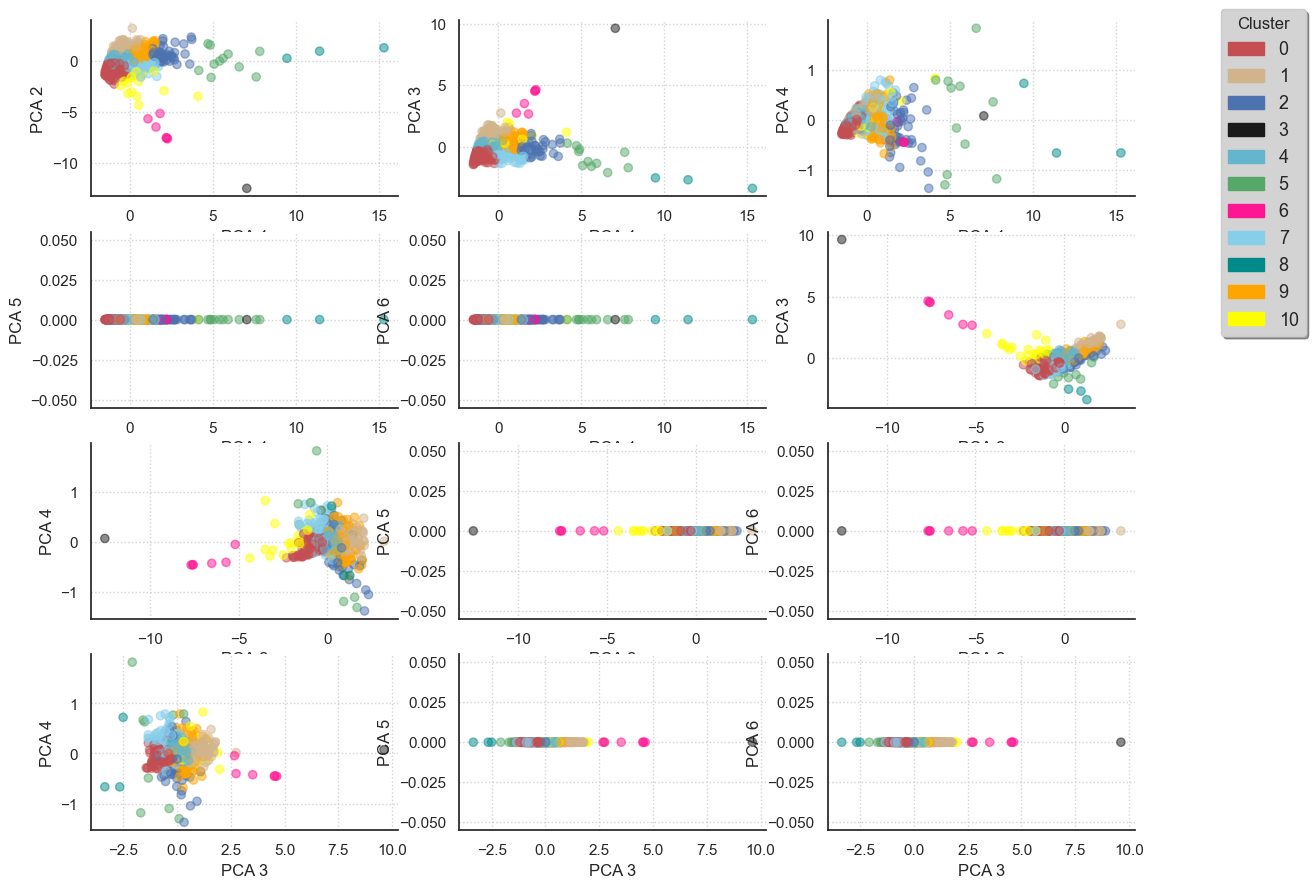

In [144]:
import matplotlib.patches as mpatches

sns.set_style("white")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2.5})

LABEL_COLOR_MAP = {0:'r', 1:'tan', 2:'b', 3:'k', 4:'c', 5:'g', 6:'deeppink', 7:'skyblue', 8:'darkcyan', 9:'orange',
                   10:'yellow', 11:'tomato', 12:'seagreen'}
label_color = [LABEL_COLOR_MAP[l] for l in mat['cluster']]

fig = plt.figure(figsize = (12,10))
increment = 0
for ix in range(6):
    for iy in range(ix+1, 6):   
        increment += 1
        ax = fig.add_subplot(4,3,increment)
        ax.scatter(mat[ix], mat[iy], c= label_color, alpha=0.5) 
        plt.ylabel('PCA {}'.format(iy+1), fontsize = 12)
        plt.xlabel('PCA {}'.format(ix+1), fontsize = 12)
        ax.yaxis.grid(color='lightgray', linestyle=':')
        ax.xaxis.grid(color='lightgray', linestyle=':')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
        if increment == 12: break
    if increment == 12: break
        
#_______________________________________________
# I set the legend: abreviation -> airline name
comp_handler = []
for i in range(n_clusters):
    comp_handler.append(mpatches.Patch(color = LABEL_COLOR_MAP[i], label = i))

plt.legend(handles=comp_handler, bbox_to_anchor=(1.1, 0.9), 
           title='Cluster', facecolor = 'lightgrey',
           shadow = True, frameon = True, framealpha = 1,
           fontsize = 13, bbox_transform = plt.gcf().transFigure)

plt.tight_layout()

From this representation, it can be seen, for example, that the first principal component allow to separate the tiniest clusters from the rest. More generally, we see that there is always a representation in which two clusters will appear to be distinct.

** b/ _Score de silhouette intra-cluster_ **

As with product categories, another way to look at the quality of the separation is to look at silouhette scores within different clusters:

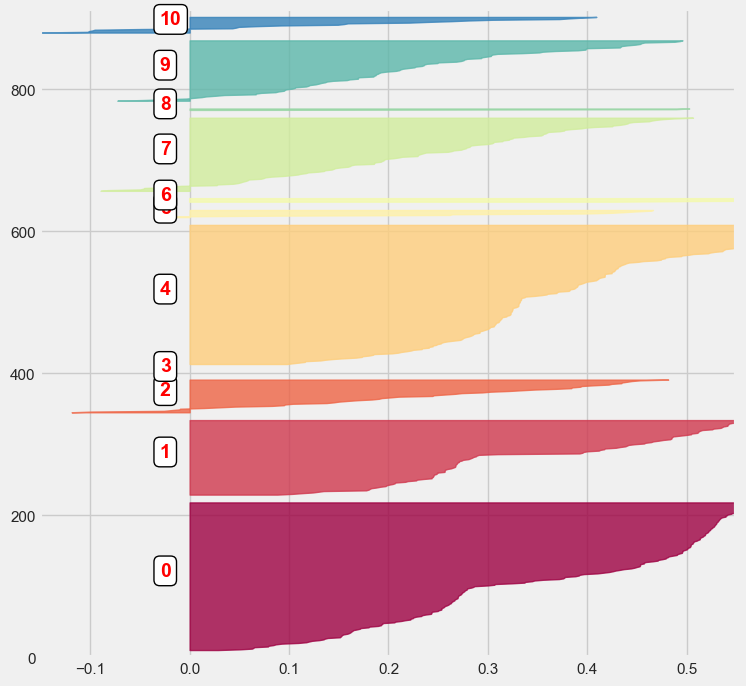

In [145]:
sample_silhouette_values = silhouette_samples(scaled_matrix, clusters_clients)
#____________________________________
# define individual silouhette scores
sample_silhouette_values = silhouette_samples(scaled_matrix, clusters_clients)
#__________________
# and do the graph
graph_component_silhouette(n_clusters, [-0.15, 0.55], len(scaled_matrix), sample_silhouette_values, clusters_clients)

** c/ _Customers morphotype_**

At this stage, I have verified that the different clusters are indeed disjoint (at least, in a global way). It remains to understand the habits of the customers in each cluster. To do so, I start by adding to the `selected_customers` dataframe a variable that defines the cluster to which each client belongs:

In [146]:
selected_customers.loc[:, 'cluster'] = clusters_clients

Then, I average the contents of this dataframe by first selecting the different groups of clients. This gives access to, for example, the average baskets price, the number of visits or the total sums spent by the clients of the different clusters. I also determine the number of clients in each group (variable ** size **):

In [148]:
import pandas as pd

merged_df = pd.DataFrame()

for i in range(n_clusters):
    # Take mean of numeric columns for this cluster
    test = selected_customers[selected_customers['cluster'] == i].mean(numeric_only=True)

    # Convert to DataFrame row
    test = test.to_frame().T

    # Add cluster id and size
    test['cluster'] = i
    test['size'] = selected_customers[selected_customers['cluster'] == i].shape[0]

    # Append
    merged_df = pd.concat([merged_df, test], ignore_index=True)

# ✅ Drop CustomerID if it exists
if 'CustomerID' in merged_df.columns:
    merged_df.drop('CustomerID', axis=1, inplace=True)

print('number of customers:', merged_df['size'].sum())

# ✅ Sort by total basket sum if column exists
if 'sum' in merged_df.columns:
    merged_df = merged_df.sort_values('sum')

print(merged_df.head())


number of customers: 793
        count         min          max        mean          sum  categ_0  \
0    3.846890   29.140751   526.870322  216.184893   852.961092      0.0   
6    1.166667  904.234833  1022.809500  963.522167  1138.221500      0.0   
4    6.868020   16.937934   942.373371  292.685570  2011.451306      0.0   
10   3.956522  255.519835  1198.104174  640.090732  2537.956357      0.0   
1   10.188679   12.579009  1086.788375  290.308734  2993.894984      0.0   

    categ_1  categ_2  categ_3  categ_4  cluster  size  
0       0.0      0.0      0.0      0.0        0   209  
6       0.0      0.0      0.0      0.0        6     6  
4       0.0      0.0      0.0      0.0        4   197  
10      0.0      0.0      0.0      0.0       10    23  
1       0.0      0.0      0.0      0.0        1   106  


Finally, I re-organize the content of the dataframe by ordering the different clusters: first, in relation to the amount wpsent in each product category and then, according to the total amount spent:

In [150]:
import pandas as pd

liste_index = []
for i in range(5):
    column = f'categ_{i}'
    # Check if any row satisfies the condition
    mask = merged_df[column] > 45
    if mask.any():
        liste_index.append(merged_df[mask].index[0])  # safe: take first index
    else:
        print(f"No row found with {column} > 45")

# Add remaining indices not already in liste_index
liste_index_reordered = liste_index + [s for s in merged_df.index if s not in liste_index]

# Reindex and reset
merged_df = merged_df.reindex(index=liste_index_reordered).reset_index(drop=True)

# Display selected columns
display(
    merged_df[['cluster','count','min','max','mean','sum',
               'categ_0','categ_1','categ_2','categ_3','categ_4','size']]
)


No row found with categ_0 > 45
No row found with categ_1 > 45
No row found with categ_2 > 45
No row found with categ_3 > 45
No row found with categ_4 > 45


,cluster,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4,size
0,0,3.846890,29.140751,526.870322,216.184893,852.961092,0.0,0.0,0.0,0.0,0.0,209
1,6,1.166667,904.234833,1022.809500,963.522167,1138.221500,0.0,0.0,0.0,0.0,0.0,6
2,4,6.868020,16.937934,942.373371,292.685570,2011.451306,0.0,0.0,0.0,0.0,0.0,197
3,10,3.956522,255.519835,1198.104174,640.090732,2537.956357,0.0,0.0,0.0,0.0,0.0,23
4,1,10.188679,12.579009,1086.788375,290.308734,2993.894984,0.0,0.0,0.0,0.0,0.0,106
5,7,4.750000,32.817942,2050.886367,672.960735,3132.667769,0.0,0.0,0.0,0.0,0.0,104
6,3,2.000000,1919.976000,3333.900000,2626.938000,5253.876000,0.0,0.0,0.0,0.0,0.0,1
7,9,8.627907,16.472233,2563.435100,612.648880,5307.626317,0.0,0.0,0.0,0.0,0.0,86
8,2,7.659574,25.480787,4805.617436,1026.558607,7736.937704,0.0,0.0,0.0,0.0,0.0,47
9,5,5.636364,86.579909,9120.640545,2250.966943,11844.249455,0.0,0.0,0.0,0.0,0.0,11


** d / _Customers morphology_ **

Finally, I created a representation of the different morphotypes. To do this, I define a class to create "Radar Charts" (which has been adapted from this [kernel](https://www.kaggle.com/yassineghouzam/don-t-know-why-employees-leave -read-this)):

In [151]:
def _scale_data(data, ranges):
    (x1, x2) = ranges[0]
    d = data[0]
    return [(d - y1) / (y2 - y1) * (x2 - x1) + x1 for d, (y1, y2) in zip(data, ranges)]

class RadarChart():
    def __init__(self, fig, location, sizes, variables, ranges, n_ordinate_levels = 6):

        angles = np.arange(0, 360, 360./len(variables))

        ix, iy = location[:] ; size_x, size_y = sizes[:]
        
        axes = [fig.add_axes([ix, iy, size_x, size_y], polar = True, 
        label = "axes{}".format(i)) for i in range(len(variables))]

        _, text = axes[0].set_thetagrids(angles, labels = variables)
        
        for txt, angle in zip(text, angles):
            if angle > -1 and angle < 181:
                txt.set_rotation(angle - 90)
            else:
                txt.set_rotation(angle - 270)
        
        for ax in axes[1:]:
            ax.patch.set_visible(False)
            ax.xaxis.set_visible(False)
            ax.grid("off")
        
        for i, ax in enumerate(axes):
            grid = np.linspace(*ranges[i],num = n_ordinate_levels)
            grid_label = [""]+["{:.0f}".format(x) for x in grid[1:-1]]
            ax.set_rgrids(grid, labels = grid_label, angle = angles[i])
            ax.set_ylim(*ranges[i])
        
        self.angle = np.deg2rad(np.r_[angles, angles[0]])
        self.ranges = ranges
        self.ax = axes[0]
                
    def plot(self, data, *args, **kw):
        sdata = _scale_data(data, self.ranges)
        self.ax.plot(self.angle, np.r_[sdata, sdata[0]], *args, **kw)

    def fill(self, data, *args, **kw):
        sdata = _scale_data(data, self.ranges)
        self.ax.fill(self.angle, np.r_[sdata, sdata[0]], *args, **kw)

    def legend(self, *args, **kw):
        self.ax.legend(*args, **kw)
        
    def title(self, title, *args, **kw):
        self.ax.text(0.9, 1, title, transform = self.ax.transAxes, *args, **kw)


This allows to have a global view of the content of each cluster:

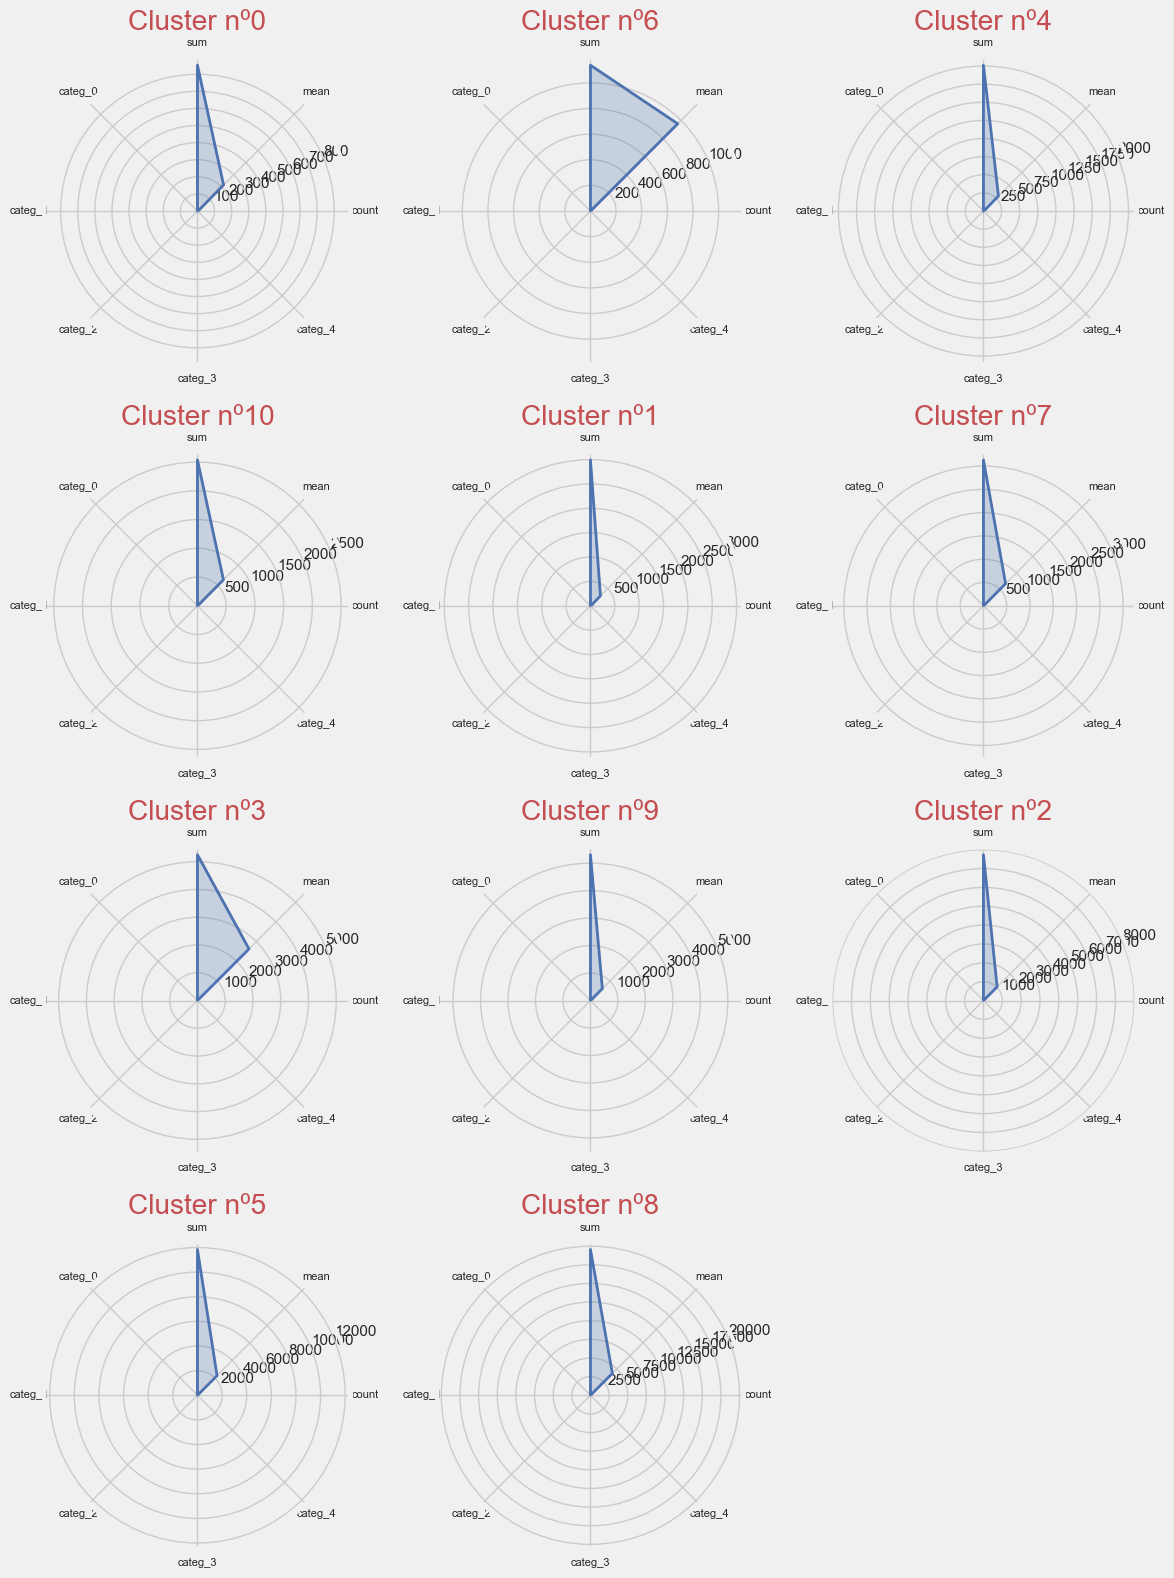

In [154]:
import matplotlib.pyplot as plt
import numpy as np

attributes = ['count','mean','sum','categ_0','categ_1','categ_2','categ_3','categ_4']
ranges = [[0.01,10],[0.01,1500],[0.01,10000],[0.01,75],[0.01,75],[0.01,75],[0.01,75],[0.01,75]]

N = len(attributes)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# ✅ Compute rows and cols automatically
cols = 3
rows = int(np.ceil(n_clusters / cols))

fig, axes = plt.subplots(rows, cols, subplot_kw=dict(polar=True), figsize=(12, 4*rows))
axes = axes.flatten()

for ind in range(n_clusters):
    ax = axes[ind]

    # Get cluster data safely by row position
    data = merged_df.loc[ind, attributes].values.flatten().tolist()
    data += data[:1]

    # Plot radar chart
    ax.plot(angles, data, color='b', linewidth=2.0)
    ax.fill(angles, data, color='b', alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(attributes, fontsize=8)
    ax.set_title(f"Cluster nº{merged_df.loc[ind,'cluster']}", color='r')

# Hide unused subplots if any
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


It can be seen, for example, that the first 5 clusters correspond to a strong preponderance of purchases in a particular category of products. Other clusters will differ from basket averages (** mean **), the total sum spent by the clients (** sum **) or the total number of visits made (** count **).

____
## 5. Classification of customers

In this part, the objective will be to adjust a classifier that will classify consumers in the different client categories that were established in the previous section. The objective is to make this classification possible at the first visit. To fulfill this objective, I will test several classifiers implemented in `scikit-learn`. First, in order to simplify their use, I define a class that allows to interface several of the functionalities common to these different classifiers: 

In [155]:
class Class_Fit(object):
    def __init__(self, clf, params=None):
        if params:            
            self.clf = clf(**params)
        else:
            self.clf = clf()

    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)

    def predict(self, x):
        return self.clf.predict(x)
    
    def grid_search(self, parameters, Kfold):
        self.grid = GridSearchCV(estimator = self.clf, param_grid = parameters, cv = Kfold)
        
    def grid_fit(self, X, Y):
        self.grid.fit(X, Y)
        
    def grid_predict(self, X, Y):
        self.predictions = self.grid.predict(X)
        print("Precision: {:.2f} % ".format(100*metrics.accuracy_score(Y, self.predictions)))
        

Since the goal is to define the class to which a client belongs and this, as soon as its first visit, I only keep the variables that describe the content of the basket, and do not take into account the variables related to the frequency of visits or variations of the basket price over time:

In [156]:
columns = ['mean', 'categ_0', 'categ_1', 'categ_2', 'categ_3', 'categ_4' ]
X = selected_customers[columns]
Y = selected_customers['cluster']

Finally, I split the dataset in train and test sets:

In [157]:
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, train_size = 0.8)

___
### 5.1 Support Vector Machine Classifier (SVC)

The first classifier I use is the SVC classifier. In order to use it, I create an instance of the `Class_Fit` class and then call` grid_search()`. When calling this method, I provide as parameters:
- the hyperparameters for which I will seek an optimal value
- the number of folds to be used for cross-validation

In [158]:
svc = Class_Fit(clf = svm.LinearSVC)
svc.grid_search(parameters = [{'C':np.logspace(-2,2,10)}], Kfold = 5)

Once this instance is created, I adjust the classifier to the training data:

In [159]:
svc.grid_fit(X = X_train, Y = Y_train)

then I can test the quality of the prediction with respect to the test data:

In [160]:
svc.grid_predict(X_test, Y_test)

Precision: 28.30 % 


___
#### 5.1.1 Confusion matrix

The accuracy of the results seems to be correct. Nevertheless, let us remember that when the different classes were defined, there was an imbalance in size between the classes obtained. In particular, one class contains around 40% of the clients. It is therefore interesting to look at how the predictions and real values compare to the breasts of the different classes. This is the subject of the confusion matrices and to represent them, I use the code of the [sklearn documentation](http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html):

In [161]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    #_________________________________________________
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)
    #_________________________________________________
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    #_________________________________________________
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

from which I create the following representation:

Confusion matrix, without normalization


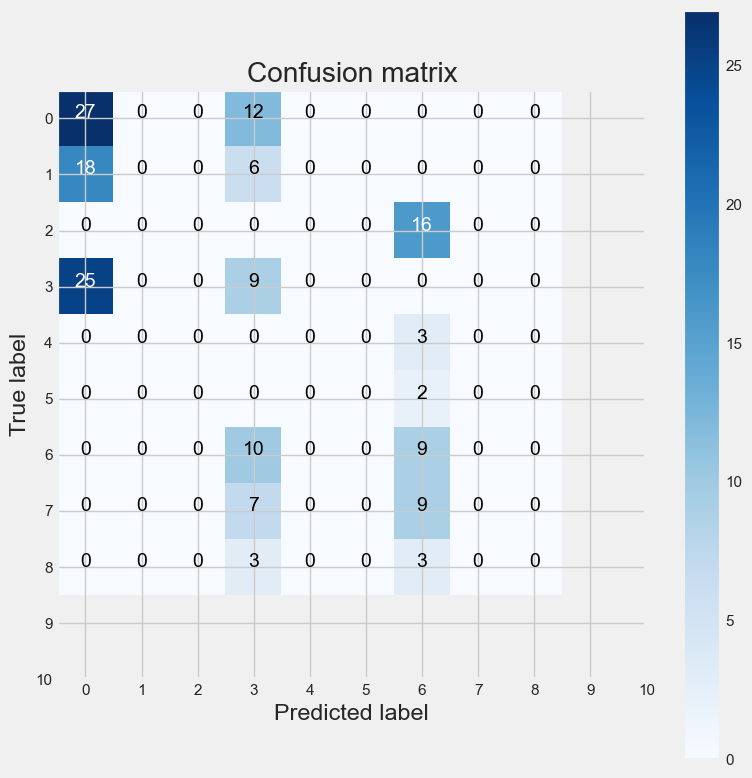

In [162]:
class_names = [i for i in range(11)]
cnf_matrix = confusion_matrix(Y_test, svc.predictions) 
np.set_printoptions(precision=2)
plt.figure(figsize = (8,8))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize = False, title='Confusion matrix')

___
#### 5.1.2 Learning curve

A typical way to test the quality of a fit is to draw a learning curve. In particular, this type of curves allow to detect possible drawbacks in the model, linked for example to over- or under-fitting. This also shows to which extent the mode could benefit from a larger data sample. In order to draw this curve, I use the [scikit-learn documentation code again](http://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html#sphx-glr- self-examples-model-selection-pad-learning-curve-py)

In [163]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    """Generate a simple plot of the test and training learning curve"""
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

from which I represent the leanring curve of the SVC classifier:

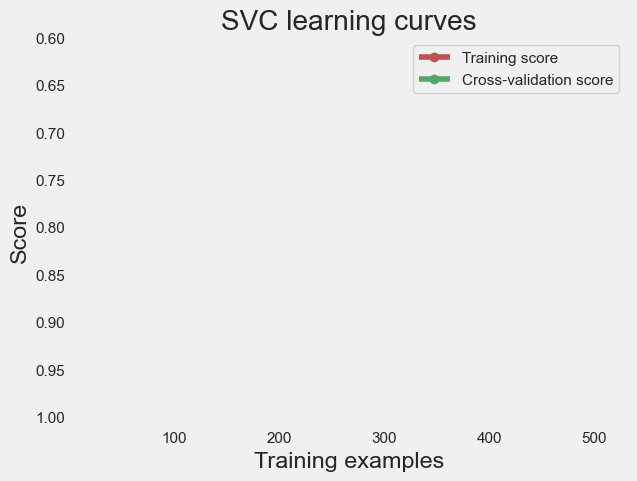

In [164]:
g = plot_learning_curve(svc.grid.best_estimator_,
                        "SVC learning curves", X_train, Y_train, ylim = [1.01, 0.6],
                        cv = 5,  train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5,
                                                0.6, 0.7, 0.8, 0.9, 1])

On this curve, we can see that the train and cross-validation curves converge towards the same limit when the sample size increases. This is typical of modeling with low variance and proves that the model does not suffer from overfitting. Also, we can see that the accuracy of the training curve is correct which is synonymous of a low bias. Hence the model does not underfit the data.

___
### 5.2 Logistic Regression

I now consider the logistic regression classifier. As before, I create an instance of the `Class_Fit` class, adjust the model on the training data and see how the predictions compare to the real values:

In [165]:
lr = Class_Fit(clf = linear_model.LogisticRegression)
lr.grid_search(parameters = [{'C':np.logspace(-2,2,20)}], Kfold = 5)
lr.grid_fit(X = X_train, Y = Y_train)
lr.grid_predict(X_test, Y_test)

Precision: 33.33 % 


Then, I plot the learning curve to have a feeling of the quality of the model:

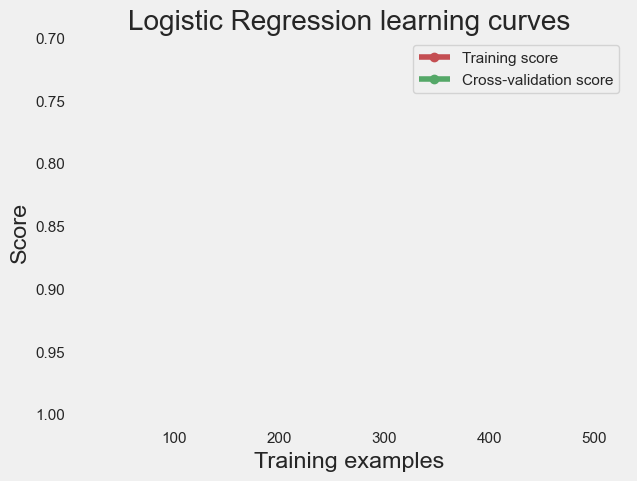

In [166]:
g = plot_learning_curve(lr.grid.best_estimator_, "Logistic Regression learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

### 5.3 k-Nearest Neighbors

In [167]:
knn = Class_Fit(clf = neighbors.KNeighborsClassifier)
knn.grid_search(parameters = [{'n_neighbors': np.arange(1,50,1)}], Kfold = 5)
knn.grid_fit(X = X_train, Y = Y_train)
knn.grid_predict(X_test, Y_test)

Precision: 40.25 % 


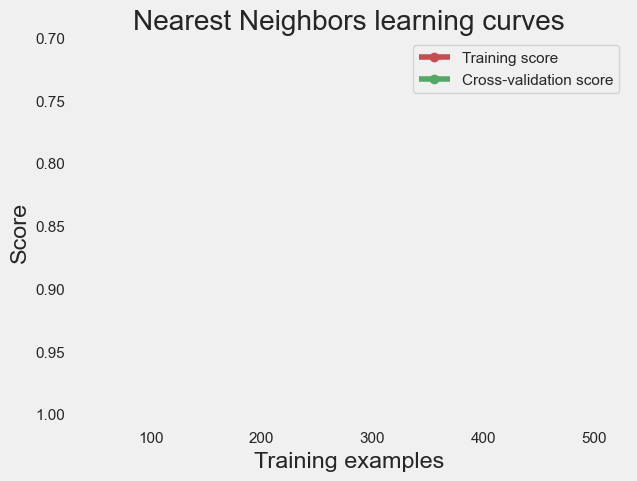

In [168]:
g = plot_learning_curve(knn.grid.best_estimator_, "Nearest Neighbors learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

### 5.4 Decision Tree

In [169]:
tr = Class_Fit(clf = tree.DecisionTreeClassifier)
tr.grid_search(parameters = [{'criterion' : ['entropy', 'gini'], 'max_features' :['sqrt', 'log2']}], Kfold = 5)
tr.grid_fit(X = X_train, Y = Y_train)
tr.grid_predict(X_test, Y_test)

Precision: 25.16 % 


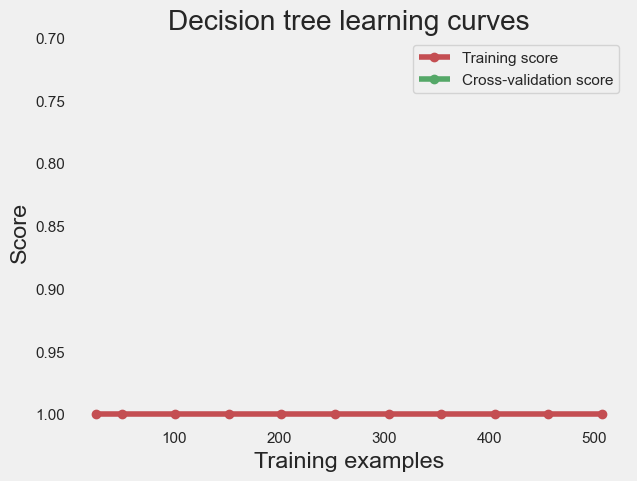

In [170]:
g = plot_learning_curve(tr.grid.best_estimator_, "Decision tree learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

### 5.5 Random Forest

In [171]:
rf = Class_Fit(clf = ensemble.RandomForestClassifier)
param_grid = {'criterion' : ['entropy', 'gini'], 'n_estimators' : [20, 40, 60, 80, 100],
               'max_features' :['sqrt', 'log2']}
rf.grid_search(parameters = param_grid, Kfold = 5)
rf.grid_fit(X = X_train, Y = Y_train)
rf.grid_predict(X_test, Y_test)

Precision: 25.16 % 


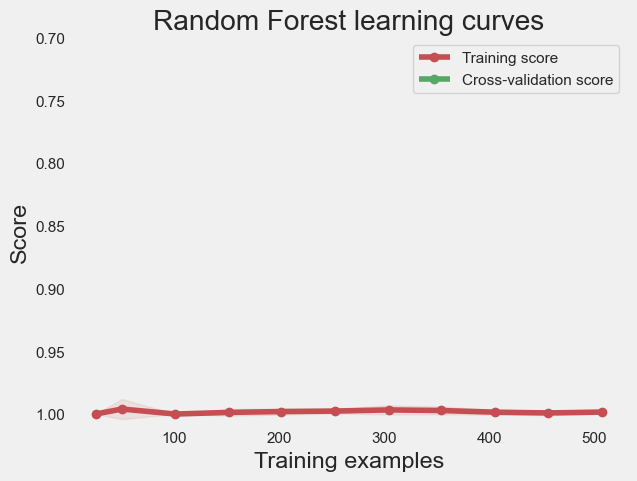

In [172]:
g = plot_learning_curve(rf.grid.best_estimator_, "Random Forest learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

### 5.6 AdaBoost Classifier

In [173]:
ada = Class_Fit(clf = AdaBoostClassifier)
param_grid = {'n_estimators' : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}
ada.grid_search(parameters = param_grid, Kfold = 5)
ada.grid_fit(X = X_train, Y = Y_train)
ada.grid_predict(X_test, Y_test)

Precision: 22.64 % 


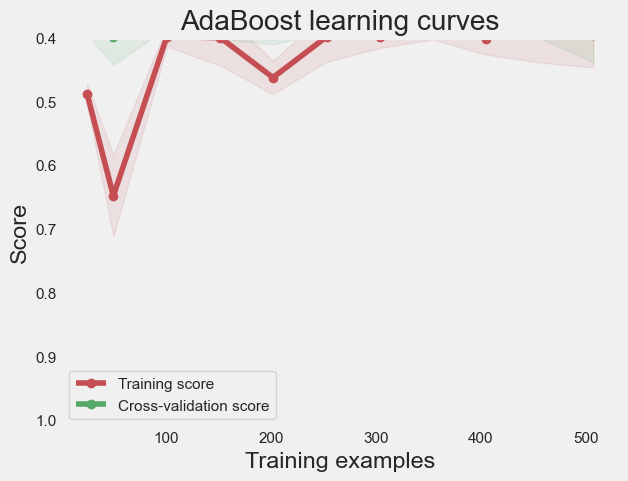

In [174]:
g = plot_learning_curve(ada.grid.best_estimator_, "AdaBoost learning curves", X_train, Y_train,
                        ylim = [1.01, 0.4], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

### 5.7 Gradient Boosting Classifier

In [175]:
gb = Class_Fit(clf = ensemble.GradientBoostingClassifier)
param_grid = {'n_estimators' : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}
gb.grid_search(parameters = param_grid, Kfold = 5)
gb.grid_fit(X = X_train, Y = Y_train)
gb.grid_predict(X_test, Y_test)

Precision: 32.70 % 


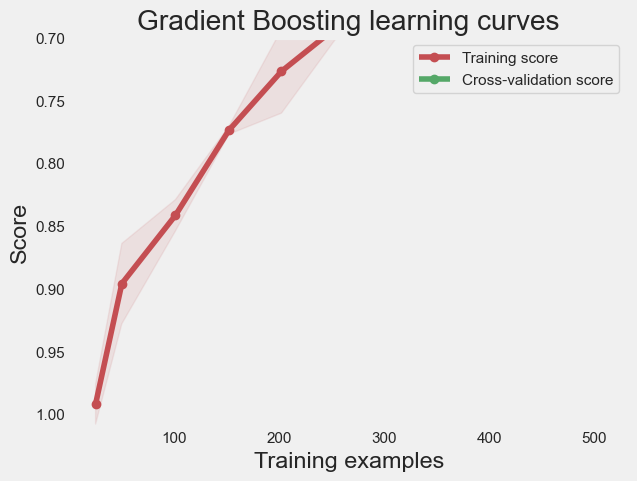

In [176]:
g = plot_learning_curve(gb.grid.best_estimator_, "Gradient Boosting learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

___
### 5.8 Let's vote !

Finally, the results of the different classifiers presented in the previous sections can be combined to improve the classification model. This can be achieved by selecting the customer category as the one indicated by the majority of classifiers. To do this, I use the `VotingClassifier` method of the `sklearn` package. As a first step, I adjust the parameters of the various classifiers using the *best* parameters previously found:

In [177]:
rf_best  = ensemble.RandomForestClassifier(**rf.grid.best_params_)
gb_best  = ensemble.GradientBoostingClassifier(**gb.grid.best_params_)
svc_best = svm.LinearSVC(**svc.grid.best_params_)
tr_best  = tree.DecisionTreeClassifier(**tr.grid.best_params_)
knn_best = neighbors.KNeighborsClassifier(**knn.grid.best_params_)
lr_best  = linear_model.LogisticRegression(**lr.grid.best_params_)

Then, I define a classifier that merges the results of the various classifiers:

In [178]:
votingC = ensemble.VotingClassifier(estimators=[('rf', rf_best),('gb', gb_best),
                                                ('knn', knn_best)], voting='soft')    

and train it:

In [179]:
votingC = votingC.fit(X_train, Y_train)

Finally, we can create a prediction for this model:

In [180]:
predictions = votingC.predict(X_test)
print("Precision: {:.2f} % ".format(100*metrics.accuracy_score(Y_test, predictions)))

Precision: 30.19 % 


Note that when defining the `votingC` classifier, I only used a sub-sample of the whole set of classifiers defined above and only retained the *Random Forest*, the *k-Nearest Neighbors* and the *Gradient Boosting* classifiers. In practice, this choice has been done with respect to the performance of the classification carried out in the next section.

___
## 6. Testing predictions

In the previous section, a few classifiers were trained in order to categorize customers. Until that point, the whole analysis was based on the data of the first 10 months. In this section, I test the model  the last two months of the dataset, that has been stored in the `set_test` dataframe:

In [181]:
basket_price = set_test.copy(deep = True)

In a first step, I regroup reformattes these data according to the same procedure as used on the training set. However, I am correcting the data to take into account the difference in time between the two datasets and weights the variables ** count ** and ** sum ** to obtain an equivalence with the training set:

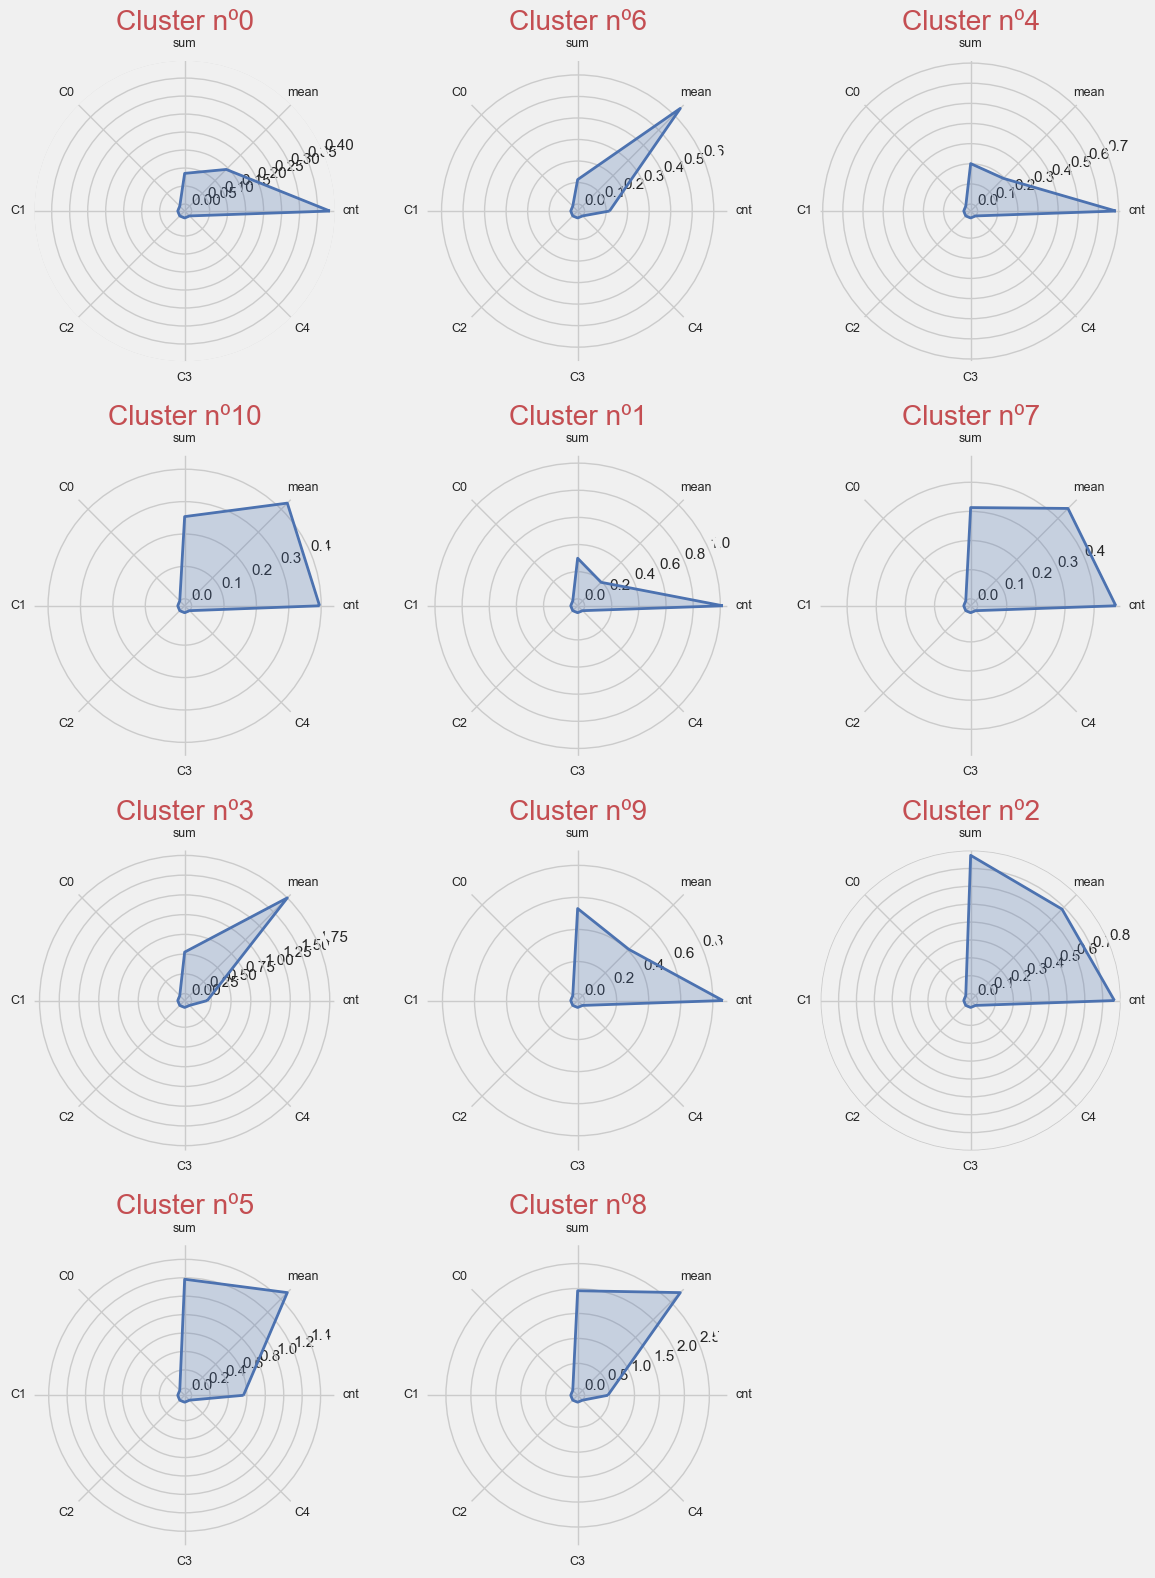

In [183]:
import matplotlib.pyplot as plt
import numpy as np

attributes = ['count','mean','sum','categ_0','categ_1','categ_2','categ_3','categ_4']
ranges = [[0.01,10],[0.01,1500],[0.01,10000],[0.01,75],[0.01,75],[0.01,75],[0.01,75],[0.01,75]]

N = len(attributes)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

cols = 3
rows = int(np.ceil(n_clusters / cols))

fig, axes = plt.subplots(rows, cols, subplot_kw=dict(polar=True), figsize=(12, 4*rows))
axes = axes.flatten()

for ind in range(n_clusters):
    ax = axes[ind]

    # Normalize values to [0,1]
    data_raw = merged_df.loc[ind, attributes].values.flatten().tolist()
    data_norm = [(val - r[0]) / (r[1] - r[0]) for val, r in zip(data_raw, ranges)]
    data_norm += data_norm[:1]

    # Plot radar chart
    ax.plot(angles, data_norm, color='b', linewidth=2.0)
    ax.fill(angles, data_norm, color='b', alpha=0.25)

    short_labels = ['cnt','mean','sum','C0','C1','C2','C3','C4']
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_title(f"Cluster nº{merged_df.loc[ind,'cluster']}", color='r')

# Hide unused subplots
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Then, I convert the dataframe into a matrix and retain only variables that define the category to which consumers belong. At this level, I recall the method of normalization that had been used on the training set:

In [185]:
import pandas as pd

list_cols = ['count','min','max','mean','categ_0','categ_1','categ_2','categ_3','categ_4']

# ✅ Convert to NumPy array
matrix_test = transactions_per_user[list_cols].to_numpy()

# ✅ Scale using your fitted scaler
scaled_test_matrix = scaler.transform(matrix_test)

print("Scaled matrix shape:", scaled_test_matrix.shape)
print(scaled_test_matrix[:5])  # show first 5 rows


Scaled matrix shape: (793, 9)
[[-0.52 -0.11  1.49  1.51  0.    0.    0.    0.    0.  ]
 [ 1.05 -0.3  -0.57 -0.79  0.    0.    0.    0.    0.  ]
 [-0.91 -0.21 -0.23 -0.03  0.    0.    0.    0.    0.  ]
 [-0.12 -0.23  0.2   0.9   0.    0.    0.    0.    0.  ]
 [-1.3  -0.23 -0.55 -0.38  0.    0.    0.    0.    0.  ]]


Each line in this matrix contains a consumer's buying habits. At this stage, it is a question of using these habits in order to define the category to which the consumer belongs. These categories have been established in Section 4. ** At this stage, it is important to bear in mind that this step does not correspond to the classification stage itself**. Here, we prepare the test data by defining the category to which the customers belong. However, this definition uses data obtained over a period of 2 months (via the variables ** count **, ** min **, ** max ** and ** sum **). The classifier defined in Section 5 uses a more restricted set of variables that will be defined from the first purchase of a client.

Here it is a question of using the available data over a period of two months and using this data to define the category to which the customers belong. Then, the classifier can be tested by comparing its predictions with these categories. In order to define the category to which the clients belong, I recall the instance of the `kmeans` method used in section 4. The` predict` method of this instance calculates the distance of the consumers from the centroids of the 11 client classes and the smallest distance will define the belonging to the different categories:

In [186]:
Y = kmeans.predict(scaled_test_matrix)

Finally, in order to prepare the execution of the classifier, it is sufficient to select the variables on which it acts:

In [187]:
columns = ['mean', 'categ_0', 'categ_1', 'categ_2', 'categ_3', 'categ_4' ]
X = transactions_per_user[columns]

It remains only to examine the predictions of the different classifiers that have been trained in section 5:

In [188]:
classifiers = [(svc, 'Support Vector Machine'),
                (lr, 'Logostic Regression'),
                (knn, 'k-Nearest Neighbors'),
                (tr, 'Decision Tree'),
                (rf, 'Random Forest'),
                (gb, 'Gradient Boosting')]
#______________________________
for clf, label in classifiers:
    print(30*'_', '\n{}'.format(label))
    clf.grid_predict(X, Y)

______________________________ 
Support Vector Machine
Precision: 37.33 % 
______________________________ 
Logostic Regression
Precision: 42.24 % 
______________________________ 
k-Nearest Neighbors
Precision: 43.38 % 
______________________________ 
Decision Tree
Precision: 84.99 % 
______________________________ 
Random Forest
Precision: 84.99 % 
______________________________ 
Gradient Boosting
Precision: 54.35 % 


Finally, as anticipated in Section 5.8, it is possible to improve the quality of the classifier by combining their respective predictions. At this level, I chose to mix *Random Forest*, *Gradient Boosting* and *k-Nearest Neighbors* predictions because this leads to a slight improvement in predictions:

In [189]:
predictions = votingC.predict(X)
print("Precision: {:.2f} % ".format(100*metrics.accuracy_score(Y, predictions)))

Precision: 76.29 % 


___
## 7. Conclusion

The work described in this notebook is based on a database providing details on purchases made on an E-commerce platform over a period of one year. Each entry in the dataset describes the purchase of a product, by a particular customer and at a given date. In total, approximately $\sim$4000 clients appear in the database. Given the available information, I decided to develop a classifier that allows to anticipate the type of purchase that a customer will make, as well as the number of visits that he will make during a year, and this from its first visit to the E-commerce site.

The first stage of this work consisted in describing the different products sold by the site, which was the subject of a first classification. There, I grouped the different products into 5 main categories of goods. In a second step, I performed a classification of the customers by analyzing their consumption habits over a period of 10 months. I have classified clients into 11 major categories based on the type of products they usually buy, the number of visits they make and the amount they spent during the 10 months. Once these categories established, I finally trained several classifiers whose objective is to be able to classify consumers in one of these 11 categories and this from their first purchase. For this, the classifier is based on 5 variables which are:
- ** mean **: amount of the basket of the current purchase
- ** categ_N ** with $N \in [0: 4]$: percentage spent in product category with index $N$

Finally, the quality of the predictions of the different classifiers was tested over the last two months of the dataset. The data were then processed in two steps: first, all the data was considered (ober the 2 months) to define the category to which each client belongs, and then, the classifier predictions were compared with this category assignment. I then found that 75% of clients are awarded the right classes.
The performance of the classifier therefore seems correct given the potential shortcomings of the current model. In particular, a bias that has not been dealt with concerns the seasonality of purchases and the fact that purchasing habits will potentially depend on the time of year (for example, Christmas ). In practice, this seasonal effect may cause the categories defined over a 10-month period to be quite different from those extrapolated from the last two months. In order to correct such bias, it would be beneficial to have data that would cover a longer period of time.

